In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df=pd.read_csv(r"C:\Users\user\Desktop\Maintenance Project\cement_maintenance_realistic_50k.csv")

In [3]:
df.head()

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type
0,4/7/2024,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive
1,4/27/2026,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective
2,12/17/2025,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive
3,4/25/2025,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective
4,4/19/2025,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         50000 non-null  object 
 1   plant_section                50000 non-null  object 
 2   major_equipment              50000 non-null  object 
 3   sub_equipment                50000 non-null  object 
 4   component                    50000 non-null  object 
 5   operating_hours              50000 non-null  float64
 6   load_percent                 50000 non-null  object 
 7   vibration_mm_s               46059 non-null  float64
 8   temperature_c                47101 non-null  object 
 9   motor_current_amp            47460 non-null  float64
 10  recommended_shelf_life_days  50000 non-null  int64  
 11  root_cause_category          50000 non-null  object 
 12  last_pm_date                 50000 non-null  object 
 13  part_install_dat

In [5]:
df.describe()

,operating_hours,vibration_mm_s,motor_current_amp,recommended_shelf_life_days,failure_within_7_days,days_to_next_failure
count,50000.000000,46059.000000,47460.000000,50000.000000,50000.000000,50000.000000
mean,15.893640,4.020139,119.946743,378.497000,0.617860,15.351832
std,4.757483,1.960133,34.944899,230.037083,0.485915,7.142852
min,0.000000,0.000000,10.000000,90.000000,0.000000,0.000000
25%,12.637639,2.656016,96.591857,180.000000,0.000000,10.400000
50%,16.002411,4.002101,119.950215,365.000000,1.000000,15.200000
75%,19.387758,5.350361,143.375094,540.000000,1.000000,20.200000
max,24.000000,12.436449,265.048154,720.000000,1.000000,46.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['operating_hours'].head()

0    22.560116
1    15.537198
2    15.058052
3    15.690068
4    20.684487
Name: operating_hours, dtype: float64

## starting with the cleaning of data

In [8]:
df.head()

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type
0,4/7/2024,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive
1,4/27/2026,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective
2,12/17/2025,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive
3,4/25/2025,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective
4,4/19/2025,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive


In [9]:
df['date'].unique()[0:500]

array(['4/7/2024', '4/27/2026', '12/17/2025', '4/25/2025', '4/19/2025',
       '7/29/2026', '4/4/2024', '2/2/2026', '8/8/2024', '4/13/2024',
       '7/30/2025', '12/4/2026', '3/16/2026', '4/13/2026', '2/24/2026',
       '5/10/2026', '7/15/2025', '5/20/2024', '7/8/2026', '5/8/2025',
       '7/1/2025', '2/10/2025', '7/18/2024', '10/11/2026', '5/5/2026',
       '12/6/2025', '3/16/2025', '6/19/2026', '8/20/2025', '4/30/2025',
       '9/5/2024', '4/10/2024', '8/30/2025', '8/30/2026', '3/10/2024',
       '7/28/2026', '6/25/2026', '10/30/2024', '11/22/2025', '6/29/2024',
       '4/10/2026', '2/6/2026', '1/23/2025', '3/15/2024', '11/28/2026',
       '5/3/2025', '9/4/2026', '1/12/2026', '5/2/2026', '4/12/2026',
       '8/1/2024', '2/2/2025', '5/26/2025', '6/29/2025', '2/17/2024',
       '8/21/2025', '6/17/2024', '3/24/2026', '1/17/2026', '10/7/2026',
       '3/26/2026', '2/5/2025', '11/25/2026', '3/25/2025', '12/22/2024',
       '9/18/2026', '2/9/2025', '3/24/2024', '5/29/2025', '5/21/2026',
  

In [10]:
df['date']=pd.to_datetime(df['date'])

In [11]:
df['date'].head()

0   2024-04-07
1   2026-04-27
2   2025-12-17
3   2025-04-25
4   2025-04-19
Name: date, dtype: datetime64[ns]

In [12]:
df['date'].isnull().sum()

np.int64(0)

In [13]:
df['date']

0       2024-04-07
1       2026-04-27
2       2025-12-17
3       2025-04-25
4       2025-04-19
           ...    
49995   2025-08-30
49996   2026-12-19
49997   2024-06-24
49998   2024-12-05
49999   2025-12-01
Name: date, Length: 50000, dtype: datetime64[ns]

In [14]:
df['year_of_recording']=df['date'].dt.year

In [15]:
df

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-08-30,workshop,Bearing Station,Press Fit,Motor,18.677808,87.15140747,2.386519,82.49690286,54.328333,90,Overload,8/27/2025,7/24/2024,1,25.7,Corrective,2025
49996,2026-12-19,Cement Mill,Ball Mill,Drive System,Belt,20.374537,69.17129487,4.726231,84.62188241,197.102480,180,Overload,9/2/2026,7/8/2026,1,11.6,Corrective,2026
49997,2024-06-24,Material Handling,Crusher,Drive Motor,Oil,20.440794,49.94%,1.986694,87.13124013,75.633154,180,Lubrication,3/10/2024,8/31/2023,0,22.3,Preventive,2024
49998,2024-12-05,Cement Mill,Ball Mill,Gearbox,Gear,11.967157,79.92015937,6.112776,76.58413566,91.244137,180,Contamination,11/3/2024,11/24/2023,1,7.6,Corrective,2024


In [16]:
df['month_of_recording']=df['date'].dt.year

In [17]:
df

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,2024
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,2026
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,2025
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,2025
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-08-30,workshop,Bearing Station,Press Fit,Motor,18.677808,87.15140747,2.386519,82.49690286,54.328333,90,Overload,8/27/2025,7/24/2024,1,25.7,Corrective,2025,2025
49996,2026-12-19,Cement Mill,Ball Mill,Drive System,Belt,20.374537,69.17129487,4.726231,84.62188241,197.102480,180,Overload,9/2/2026,7/8/2026,1,11.6,Corrective,2026,2026
49997,2024-06-24,Material Handling,Crusher,Drive Motor,Oil,20.440794,49.94%,1.986694,87.13124013,75.633154,180,Lubrication,3/10/2024,8/31/2023,0,22.3,Preventive,2024,2024
49998,2024-12-05,Cement Mill,Ball Mill,Gearbox,Gear,11.967157,79.92015937,6.112776,76.58413566,91.244137,180,Contamination,11/3/2024,11/24/2023,1,7.6,Corrective,2024,2024


In [18]:
df['month_of_recording']=df['date'].dt.month

In [19]:
df

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-08-30,workshop,Bearing Station,Press Fit,Motor,18.677808,87.15140747,2.386519,82.49690286,54.328333,90,Overload,8/27/2025,7/24/2024,1,25.7,Corrective,2025,8
49996,2026-12-19,Cement Mill,Ball Mill,Drive System,Belt,20.374537,69.17129487,4.726231,84.62188241,197.102480,180,Overload,9/2/2026,7/8/2026,1,11.6,Corrective,2026,12
49997,2024-06-24,Material Handling,Crusher,Drive Motor,Oil,20.440794,49.94%,1.986694,87.13124013,75.633154,180,Lubrication,3/10/2024,8/31/2023,0,22.3,Preventive,2024,6
49998,2024-12-05,Cement Mill,Ball Mill,Gearbox,Gear,11.967157,79.92015937,6.112776,76.58413566,91.244137,180,Contamination,11/3/2024,11/24/2023,1,7.6,Corrective,2024,12


In [20]:
df2=df.copy()

In [21]:
df2

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-08-30,workshop,Bearing Station,Press Fit,Motor,18.677808,87.15140747,2.386519,82.49690286,54.328333,90,Overload,8/27/2025,7/24/2024,1,25.7,Corrective,2025,8
49996,2026-12-19,Cement Mill,Ball Mill,Drive System,Belt,20.374537,69.17129487,4.726231,84.62188241,197.102480,180,Overload,9/2/2026,7/8/2026,1,11.6,Corrective,2026,12
49997,2024-06-24,Material Handling,Crusher,Drive Motor,Oil,20.440794,49.94%,1.986694,87.13124013,75.633154,180,Lubrication,3/10/2024,8/31/2023,0,22.3,Preventive,2024,6
49998,2024-12-05,Cement Mill,Ball Mill,Gearbox,Gear,11.967157,79.92015937,6.112776,76.58413566,91.244137,180,Contamination,11/3/2024,11/24/2023,1,7.6,Corrective,2024,12


In [22]:
df2=df2.drop(columns=['date'])

In [23]:
df2

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,workshop,Bearing Station,Press Fit,Motor,18.677808,87.15140747,2.386519,82.49690286,54.328333,90,Overload,8/27/2025,7/24/2024,1,25.7,Corrective,2025,8
49996,Cement Mill,Ball Mill,Drive System,Belt,20.374537,69.17129487,4.726231,84.62188241,197.102480,180,Overload,9/2/2026,7/8/2026,1,11.6,Corrective,2026,12
49997,Material Handling,Crusher,Drive Motor,Oil,20.440794,49.94%,1.986694,87.13124013,75.633154,180,Lubrication,3/10/2024,8/31/2023,0,22.3,Preventive,2024,6
49998,Cement Mill,Ball Mill,Gearbox,Gear,11.967157,79.92015937,6.112776,76.58413566,91.244137,180,Contamination,11/3/2024,11/24/2023,1,7.6,Corrective,2024,12


In [24]:
df2['plant_section'].value_counts()

plant_section
Kiln                 7018
Utilities            6972
Workshop             6866
Material Handling    6793
Cement Mill          6776
Raw Mill             6732
Packing Plant        6706
CEMENT MILL           147
workshop              136
MATERIAL HANDLING     135
PACKING PLANT         128
Material_Handling     125
KILN                  124
RAW MILL              120
UTILITIES             120
Cement_Mill           119
packing plant         119
raw mill              116
Packing_Plant         115
kiln                  112
material handling     107
utilities             107
cement mill           107
Raw_Mill              101
WORKSHOP               99
Name: count, dtype: int64

In [25]:
df2['plant_section']=df2['plant_section'].str.lower()

In [26]:
df2['plant_section'].value_counts()

plant_section
kiln                 7254
utilities            7199
workshop             7101
material handling    7035
cement mill          7030
raw mill             6968
packing plant        6953
material_handling     125
cement_mill           119
packing_plant         115
raw_mill              101
Name: count, dtype: int64

In [27]:
mapp_sections={
    'cement_mill':'cement mill',
    'material_handling':'material handling',
    'packing_plant':'packing plant',
    'raw_mill':'raw mill'
}

In [28]:
df2['plant_section'].replace(mapp_sections)

0              cement mill
1                 workshop
2                 raw mill
3                 workshop
4                     kiln
               ...        
49995             workshop
49996          cement mill
49997    material handling
49998          cement mill
49999             workshop
Name: plant_section, Length: 50000, dtype: object

In [29]:
df2['plant_section']=df2['plant_section'].replace(mapp_sections)

In [30]:
df2['plant_section'].value_counts()

plant_section
kiln                 7254
utilities            7199
material handling    7160
cement mill          7149
workshop             7101
raw mill             7069
packing plant        7068
Name: count, dtype: int64

In [31]:
df2['plant_section']=df2['plant_section'].str.capitalize()

In [32]:
df2['plant_section'].value_counts()

plant_section
Kiln                 7254
Utilities            7199
Material handling    7160
Cement mill          7149
Workshop             7101
Raw mill             7069
Packing plant        7068
Name: count, dtype: int64

In [33]:
df2['plant_section']=df2['plant_section'].str.strip()

In [34]:
df2['plant_section'].isnull().sum()

np.int64(0)

In [35]:
df.head()

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4


In [36]:
df2.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,Cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,Raw mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4


In [37]:
df2['major_equipment'].value_counts()

major_equipment
Conveyor           7049
Air Compressor     2470
Crusher            2432
Cooler             2430
Rotary Kiln        2430
Bearing Station    2405
Fan                2402
Gearbox System     2401
Separator          2400
ID Fan             2394
Bag Filter         2381
Overhaul Bench     2369
Pump               2366
Generator          2363
Rotary Packer      2359
Bucket Elevator    2357
Ball Mill          2348
Gearbox Bay        2327
Raw Mill           2317
Name: count, dtype: int64

In [38]:
df2['major_equipment'].unique()

array(['Gearbox System', 'Bearing Station', 'Raw Mill', 'Gearbox Bay',
       'Rotary Kiln', 'Pump', 'Fan', 'Conveyor', 'Rotary Packer',
       'Generator', 'Crusher', 'ID Fan', 'Separator', 'Bucket Elevator',
       'Cooler', 'Ball Mill', 'Air Compressor', 'Overhaul Bench',
       'Bag Filter'], dtype=object)

## important step from df- Checking dupicates excluding the dates


In [39]:
df.drop(columns=['date']).duplicated().sum()

np.int64(0)

In [40]:
df2['major_equipment']=df2['major_equipment'].str.strip()

In [41]:
df2['major_equipment'].value_counts()

major_equipment
Conveyor           7049
Air Compressor     2470
Crusher            2432
Cooler             2430
Rotary Kiln        2430
Bearing Station    2405
Fan                2402
Gearbox System     2401
Separator          2400
ID Fan             2394
Bag Filter         2381
Overhaul Bench     2369
Pump               2366
Generator          2363
Rotary Packer      2359
Bucket Elevator    2357
Ball Mill          2348
Gearbox Bay        2327
Raw Mill           2317
Name: count, dtype: int64

In [42]:
df2.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,Cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,Raw mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4


In [43]:
df2['sub_equipment'].value_counts()

sub_equipment
Gearbox             4799
Bearings            3280
Motor               3183
Drive Motor         3099
General             2402
Idlers              1796
Belt                1720
Filters             1588
Rotor               1563
Impeller            1554
Lubrication         1461
Drive System        1351
Inspection          1220
Assembly            1149
Drive                845
Air Dryer            836
Cleaning             823
Cooling              823
Grate                822
Support Rollers      818
Seal                 818
Greasing             815
Filter Bags          795
Oil Pump             795
Fan                  795
Disassembly          793
Pulse Jet            791
Rebuild              791
Alternator           791
Main Drive           771
Press Fit            767
Head Pulley          763
Fans                 763
Belt/Chain           759
Fuel System          749
Oil Flush            743
Air System           618
Weighing System      609
Trunnion Bearing     572
Spouts     

In [44]:
df2['sub_equipment'].unique()

array(['Filters', 'Greasing', 'Gearbox', 'Disassembly', 'Support Rollers',
       'Impeller', 'General', 'Drive Motor', 'Air System', 'Cooling',
       'Weighing System', 'Seal', 'Motor', 'Bearings', 'Main Drive',
       'Oil Flush', 'Alternator', 'Idlers', 'Fans', 'Rotor', 'Spouts',
       'Drive System', 'Belt/Chain', 'Air Dryer', 'Inspection',
       'Press Fit', 'Fuel System', 'Filter Bags', 'Cleaning',
       'Head Pulley', 'Trunnion Bearing', 'Oil Pump', 'Belt', 'Assembly',
       'Pulse Jet', 'Drive', 'Grate', 'Lubrication', 'Fan', 'Rebuild'],
      dtype=object)

In [45]:
df2['sub_equipment']=df2['sub_equipment'].str.strip()  

In [46]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                50000 non-null  object 
 1   major_equipment              50000 non-null  object 
 2   sub_equipment                50000 non-null  object 
 3   component                    50000 non-null  object 
 4   operating_hours              50000 non-null  float64
 5   load_percent                 50000 non-null  object 
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                47101 non-null  object 
 8   motor_current_amp            47460 non-null  float64
 9   recommended_shelf_life_days  50000 non-null  int64  
 10  root_cause_category          50000 non-null  object 
 11  last_pm_date                 50000 non-null  object 
 12  part_install_date            50000 non-null  object 
 13  failure_within_7

In [47]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         50000 non-null  datetime64[ns]
 1   plant_section                50000 non-null  object        
 2   major_equipment              50000 non-null  object        
 3   sub_equipment                50000 non-null  object        
 4   component                    50000 non-null  object        
 5   operating_hours              50000 non-null  float64       
 6   load_percent                 50000 non-null  object        
 7   vibration_mm_s               46059 non-null  float64       
 8   temperature_c                47101 non-null  object        
 9   motor_current_amp            47460 non-null  float64       
 10  recommended_shelf_life_days  50000 non-null  int64         
 11  root_cause_category          50000 non-nu

In [48]:
df2['component'].value_counts()

component
Motor       5642
Belt        5613
Coupling    5598
Bearing     5597
Impeller    5567
Seal        5542
Filter      5525
Gear        5465
Oil         5451
Name: count, dtype: int64

In [49]:
df2['component'].isnull().sum()

np.int64(0)

In [50]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                50000 non-null  object 
 1   major_equipment              50000 non-null  object 
 2   sub_equipment                50000 non-null  object 
 3   component                    50000 non-null  object 
 4   operating_hours              50000 non-null  float64
 5   load_percent                 50000 non-null  object 
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                47101 non-null  object 
 8   motor_current_amp            47460 non-null  float64
 9   recommended_shelf_life_days  50000 non-null  int64  
 10  root_cause_category          50000 non-null  object 
 11  last_pm_date                 50000 non-null  object 
 12  part_install_date            50000 non-null  object 
 13  failure_within_7

In [51]:
df2['component']=df2['component'].str.strip()

In [52]:
df2['component'].value_counts()

component
Motor       5642
Belt        5613
Coupling    5598
Bearing     5597
Impeller    5567
Seal        5542
Filter      5525
Gear        5465
Oil         5451
Name: count, dtype: int64

In [53]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                50000 non-null  object 
 1   major_equipment              50000 non-null  object 
 2   sub_equipment                50000 non-null  object 
 3   component                    50000 non-null  object 
 4   operating_hours              50000 non-null  float64
 5   load_percent                 50000 non-null  object 
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                47101 non-null  object 
 8   motor_current_amp            47460 non-null  float64
 9   recommended_shelf_life_days  50000 non-null  int64  
 10  root_cause_category          50000 non-null  object 
 11  last_pm_date                 50000 non-null  object 
 12  part_install_date            50000 non-null  object 
 13  failure_within_7

In [54]:
df2['operating_hours'].describe()

count    50000.000000
mean        15.893640
std          4.757483
min          0.000000
25%         12.637639
50%         16.002411
75%         19.387758
max         24.000000
Name: operating_hours, dtype: float64

In [55]:
#looking at the distribution for the operating hours

Text(0.5, 1.0, 'Opertaing Hours Distribution')

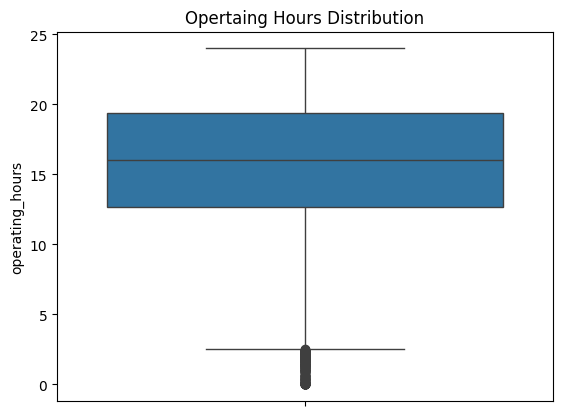

In [56]:
sns.boxplot(df2['operating_hours'])
plt.title("Opertaing Hours Distribution")

In [57]:
#from boxplot there are no outliers but we need to round off by two

In [58]:
df2['operating_hours'].round(2)

0        22.56
1        15.54
2        15.06
3        15.69
4        20.68
         ...  
49995    18.68
49996    20.37
49997    20.44
49998    11.97
49999    23.03
Name: operating_hours, Length: 50000, dtype: float64

In [59]:
df2['operating_hours']=df2['operating_hours'].round(2)

In [60]:
df2['operating_hours'].head()

0    22.56
1    15.54
2    15.06
3    15.69
4    20.68
Name: operating_hours, dtype: float64

In [61]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                50000 non-null  object 
 1   major_equipment              50000 non-null  object 
 2   sub_equipment                50000 non-null  object 
 3   component                    50000 non-null  object 
 4   operating_hours              50000 non-null  float64
 5   load_percent                 50000 non-null  object 
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                47101 non-null  object 
 8   motor_current_amp            47460 non-null  float64
 9   recommended_shelf_life_days  50000 non-null  int64  
 10  root_cause_category          50000 non-null  object 
 11  last_pm_date                 50000 non-null  object 
 12  part_install_date            50000 non-null  object 
 13  failure_within_7

In [62]:
df2['operating_hours'].isnull().sum()

np.int64(0)

In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                50000 non-null  object 
 1   major_equipment              50000 non-null  object 
 2   sub_equipment                50000 non-null  object 
 3   component                    50000 non-null  object 
 4   operating_hours              50000 non-null  float64
 5   load_percent                 50000 non-null  object 
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                47101 non-null  object 
 8   motor_current_amp            47460 non-null  float64
 9   recommended_shelf_life_days  50000 non-null  int64  
 10  root_cause_category          50000 non-null  object 
 11  last_pm_date                 50000 non-null  object 
 12  part_install_date            50000 non-null  object 
 13  failure_within_7

## moving on to the load_percent column

In [64]:
df2.duplicated().drop(columns=['load_percent']).sum()

np.int64(0)

In [65]:
df2['load_percent'].head()

0    45.66035665
1    57.34295024
2    83.42828683
3    70.85487452
4     69.0366604
Name: load_percent, dtype: object

In [66]:
df2['load_percent'].isnull().sum()

np.int64(0)

In [67]:
df2['load_percent'].describe()

count     50000
unique    49017
top         110
freq        469
Name: load_percent, dtype: object

In [68]:
## looking for unusual characters in the load_percent column

In [69]:
df2['load_percent'][df2['load_percent'].str.contains(r'[^0-9]',regex=True)]

0        45.66035665
1        57.34295024
2        83.42828683
3        70.85487452
4         69.0366604
            ...     
49995    87.15140747
49996    69.17129487
49997         49.94%
49998    79.92015937
49999    67.92052321
Name: load_percent, Length: 49531, dtype: object

In [70]:
## we have to first remove the % sign in the columns
df2['load_percent'].str.replace('%','')

0        45.66035665
1        57.34295024
2        83.42828683
3        70.85487452
4         69.0366604
            ...     
49995    87.15140747
49996    69.17129487
49997          49.94
49998    79.92015937
49999    67.92052321
Name: load_percent, Length: 50000, dtype: object

In [71]:
df2['load_percent']=df2['load_percent'].str.replace('%','')

In [72]:
df2['load_percent'][df2['load_percent'].str.contains(r'[^0-9]',regex=True)]

0        45.66035665
1        57.34295024
2        83.42828683
3        70.85487452
4         69.0366604
            ...     
49995    87.15140747
49996    69.17129487
49997          49.94
49998    79.92015937
49999    67.92052321
Name: load_percent, Length: 49531, dtype: object

In [73]:
pd.to_numeric(df2['load_percent'])

0        45.660357
1        57.342950
2        83.428287
3        70.854875
4        69.036660
           ...    
49995    87.151407
49996    69.171295
49997    49.940000
49998    79.920159
49999    67.920523
Name: load_percent, Length: 50000, dtype: float64

In [74]:
df2['load_percent']=pd.to_numeric(df2['load_percent'])

In [75]:
df2['load_percent'].describe()

count    50000.000000
mean        75.013338
std         14.839406
min          1.076423
25%         64.946627
50%         75.143267
75%         85.199808
max        110.000000
Name: load_percent, dtype: float64

Text(0.5, 1.0, 'Distribution Of Percentages')

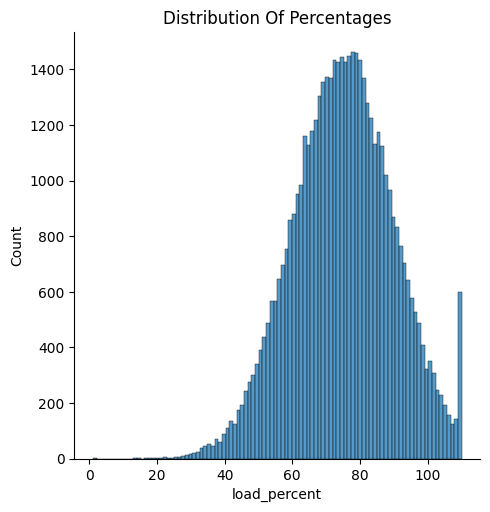

In [76]:
sns.displot(df2['load_percent'])
plt.title("Distribution Of Percentages")

Text(0.5, 1.0, 'Distribution Of Percentages')

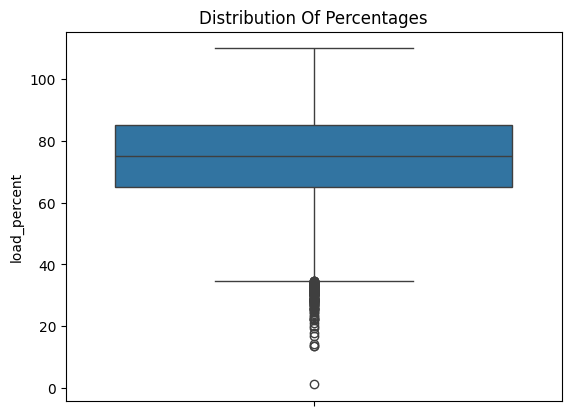

In [77]:
sns.boxplot(df2['load_percent'])
plt.title("Distribution Of Percentages")

In [78]:
Q1=df2['load_percent'].quantile(0.25)
Q3=df2['load_percent'].quantile(0.75)

In [79]:
IQR=Q3-Q1

In [80]:
lower_bound=Q1-1.5*IQR

In [81]:
#counting the lower outliers and looking at them
df2[df2['load_percent']<lower_bound].shape

(177, 18)

In [82]:
upper_bound=Q3+1.5*IQR

In [83]:
df2[df2['load_percent']>upper_bound].shape

(0, 18)

In [84]:
(df2['load_percent']<lower_bound).astype(int)

0        0
1        0
2        0
3        0
4        0
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Name: load_percent, Length: 50000, dtype: int64

In [85]:
df2['low_load_flag']=(df2['load_percent']<lower_bound).astype(int)

In [86]:
df2.groupby('failure_within_7_days')['load_percent'].mean()

failure_within_7_days
0    73.538279
1    75.925648
Name: load_percent, dtype: float64

Text(0.5, 1.0, 'Relationship Between Load and Failure')

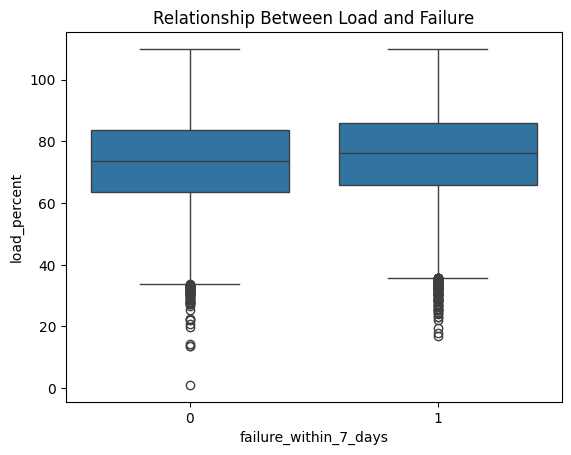

In [87]:
sns.boxplot(x='failure_within_7_days',y='load_percent',data=df2)
plt.title("Relationship Between Load and Failure")

In [88]:
df2['load_percent']=df2['load_percent'].round(2)

In [89]:
df2.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording,low_load_flag
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4,0
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4,0
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12,0
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4,0
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4,0


In [90]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                50000 non-null  object 
 1   major_equipment              50000 non-null  object 
 2   sub_equipment                50000 non-null  object 
 3   component                    50000 non-null  object 
 4   operating_hours              50000 non-null  float64
 5   load_percent                 50000 non-null  float64
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                47101 non-null  object 
 8   motor_current_amp            47460 non-null  float64
 9   recommended_shelf_life_days  50000 non-null  int64  
 10  root_cause_category          50000 non-null  object 
 11  last_pm_date                 50000 non-null  object 
 12  part_install_date            50000 non-null  object 
 13  failure_within_7

In [91]:
# moving on to the next column vibration_mm_s

In [92]:
df2['vibration_mm_s'].describe()

count    46059.000000
mean         4.020139
std          1.960133
min          0.000000
25%          2.656016
50%          4.002101
75%          5.350361
max         12.436449
Name: vibration_mm_s, dtype: float64

In [93]:
df2.dropna(subset=['vibration_mm_s'],inplace=True)

In [94]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46059 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                46059 non-null  object 
 1   major_equipment              46059 non-null  object 
 2   sub_equipment                46059 non-null  object 
 3   component                    46059 non-null  object 
 4   operating_hours              46059 non-null  float64
 5   load_percent                 46059 non-null  float64
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                43397 non-null  object 
 8   motor_current_amp            43745 non-null  float64
 9   recommended_shelf_life_days  46059 non-null  int64  
 10  root_cause_category          46059 non-null  object 
 11  last_pm_date                 46059 non-null  object 
 12  part_install_date            46059 non-null  object 
 13  failure_within_7_days

Text(0.5, 1.0, 'Distribution Of Vibration')

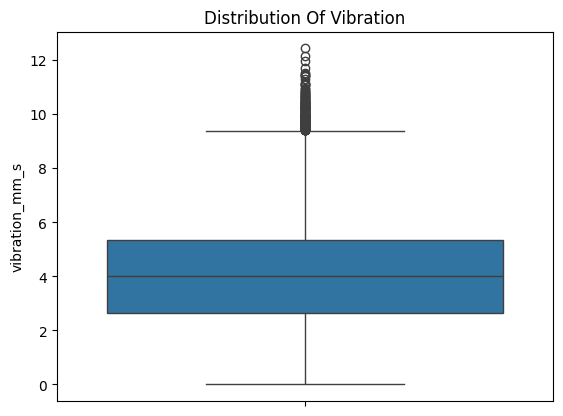

In [95]:
sns.boxplot(df2['vibration_mm_s'])
plt.title("Distribution Of Vibration")

Text(0.5, 1.0, 'Distribution Of Vibration')

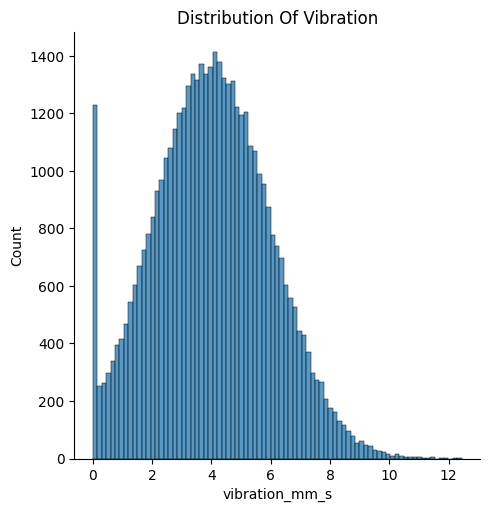

In [96]:
sns.displot(df2['vibration_mm_s'])
plt.title("Distribution Of Vibration")

In [97]:
Q1=df2['vibration_mm_s'].quantile(0.25)
Q3=df2['vibration_mm_s'].quantile(0.75)

In [98]:
IQR=Q3-Q1

In [99]:
upper_bound=Q3+1.5*IQR

In [100]:
df2[df2['vibration_mm_s']>upper_bound].shape

(175, 19)

In [101]:
(df2['vibration_mm_s']>upper_bound).astype(int)

0        0
1        0
2        0
3        0
4        0
        ..
49995    0
49996    0
49997    0
49998    0
49999    0
Name: vibration_mm_s, Length: 46059, dtype: int64

In [102]:
df2['high_viibration_flag']=(df2['vibration_mm_s']>upper_bound).astype(int)

In [103]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46059 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                46059 non-null  object 
 1   major_equipment              46059 non-null  object 
 2   sub_equipment                46059 non-null  object 
 3   component                    46059 non-null  object 
 4   operating_hours              46059 non-null  float64
 5   load_percent                 46059 non-null  float64
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                43397 non-null  object 
 8   motor_current_amp            43745 non-null  float64
 9   recommended_shelf_life_days  46059 non-null  int64  
 10  root_cause_category          46059 non-null  object 
 11  last_pm_date                 46059 non-null  object 
 12  part_install_date            46059 non-null  object 
 13  failure_within_7_days

In [104]:
df2.groupby('failure_within_7_days')['vibration_mm_s'].mean()

failure_within_7_days
0    3.528525
1    4.323360
Name: vibration_mm_s, dtype: float64

Text(0.5, 1.0, 'Correlation between Failure and Vibration')

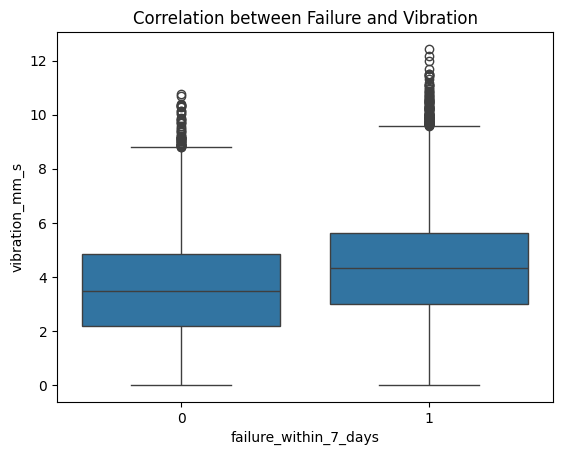

In [105]:
sns.boxplot(x='failure_within_7_days',y='vibration_mm_s',data=df2)
plt.title("Correlation between Failure and Vibration")

In [106]:
df2['vibration_mm_s']=df2['vibration_mm_s'].round(2)

In [107]:
df2.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4,0,0
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4,0,0
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12,0,0
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4,0,0
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4,0,0


In [108]:
df2['temperature_c'].head()

0          82.61548865
1    81.7327296797816C
2          72.75185086
3           71.2237025
4          59.99660913
Name: temperature_c, dtype: object

In [109]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46059 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                46059 non-null  object 
 1   major_equipment              46059 non-null  object 
 2   sub_equipment                46059 non-null  object 
 3   component                    46059 non-null  object 
 4   operating_hours              46059 non-null  float64
 5   load_percent                 46059 non-null  float64
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                43397 non-null  object 
 8   motor_current_amp            43745 non-null  float64
 9   recommended_shelf_life_days  46059 non-null  int64  
 10  root_cause_category          46059 non-null  object 
 11  last_pm_date                 46059 non-null  object 
 12  part_install_date            46059 non-null  object 
 13  failure_within_7_days

In [110]:
df2['temperature_c'].isnull().sum()

np.int64(2662)

In [111]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46059 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                46059 non-null  object 
 1   major_equipment              46059 non-null  object 
 2   sub_equipment                46059 non-null  object 
 3   component                    46059 non-null  object 
 4   operating_hours              46059 non-null  float64
 5   load_percent                 46059 non-null  float64
 6   vibration_mm_s               46059 non-null  float64
 7   temperature_c                43397 non-null  object 
 8   motor_current_amp            43745 non-null  float64
 9   recommended_shelf_life_days  46059 non-null  int64  
 10  root_cause_category          46059 non-null  object 
 11  last_pm_date                 46059 non-null  object 
 12  part_install_date            46059 non-null  object 
 13  failure_within_7_days

In [112]:
df2.loc[df2['temperature_c'].astype(str).str.contains(r'[^0-9.-]',regex=True),'temperature_c'].unique()[0:100]

array(['81.7327296797816C', '70.66728000715405C', '88.13068082227882C',
       '113.77753841384157C', '83.14540129472793C', '64.8398323867065C',
       '72.55707767289813C', nan, '50.35305993982328C',
       '85.48128132850155C', '74.21103904150777C', '75.9654239997404C',
       '85.65354108739696C', '79.66659817196137C', '76.03059349354855C',
       '82.19617998995683C', '67.73013271906513C', '99.6560774676062C',
       '71.2661644553471C', '85.6292837715539C', '102.78263657399333C',
       '88.06757657191635C', '120.75369044196559C', '84.69657688761593C',
       '55.08246870678533C', '102.7094435350565C', '84.72263492198161C',
       '55.326285289021584C', '100.203037014226C', '86.31106772654961C',
       '88.37112096010756C', '78.139079064957C', 'nanC',
       '76.63484513672307C', '49.02276353732452C', '90.2985389801795C',
       '65.07384906898685C', '104.54460855150317C', '87.5150756978494C',
       '78.26265294799532C', '85.7735568828149C', '73.74373525341552C',
       '63.40564

In [113]:
df2.loc[df2['temperature_c'].astype(str).str.contains(r'[^0-9.-]',regex=True),'temperature_c'].value_counts()

temperature_c
nanC                   125
81.7327296797816C        1
61.522815597326655C      1
61.800047176423774C      1
69.52876893284534C       1
                      ... 
72.28655810307873C       1
81.70906409439624C       1
63.23151115034267C       1
70.41435359780289C       1
61.94149383015307C       1
Name: count, Length: 2184, dtype: int64

In [114]:
df2['temperature_c']=df2['temperature_c'].str.replace('C','')

In [115]:
df2.loc[df2['temperature_c'].astype(str).str.contains(r'[^0-9.-]',regex=True),'temperature_c'].unique()[0:100]

array([nan, 'nan'], dtype=object)

In [116]:
df2['temperature_c'].isnull().sum()

np.int64(2662)

In [117]:
df2.dropna(subset=['temperature_c'],inplace=True)

In [118]:
not_a_number=df2.loc[df2['temperature_c'].astype(str).str.contains(r'[^0-9.-]',regex=True),'temperature_c'].unique()

In [119]:
df2['temperature_c'].isnull().sum()

np.int64(0)

In [120]:
#no nulls in the temperature column thus we need to change the data type

In [121]:
pd.to_numeric(df2['temperature_c'],errors='coerce').round(2)

0        82.62
1        81.73
2        72.75
3        71.22
4        60.00
         ...  
49995    82.50
49996    84.62
49997    87.13
49998    76.58
49999    73.39
Name: temperature_c, Length: 43397, dtype: float64

In [122]:
df2['temperature_c']=pd.to_numeric(df2['temperature_c'],errors='coerce').round(2)

In [123]:
df2['temperature_c'].isnull().sum()

np.int64(125)

In [124]:
df2.dropna(subset=['temperature_c'],inplace=True)

In [125]:
df2['temperature_c'].isnull().sum()

np.int64(0)

In [126]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43272 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                43272 non-null  object 
 1   major_equipment              43272 non-null  object 
 2   sub_equipment                43272 non-null  object 
 3   component                    43272 non-null  object 
 4   operating_hours              43272 non-null  float64
 5   load_percent                 43272 non-null  float64
 6   vibration_mm_s               43272 non-null  float64
 7   temperature_c                43272 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  43272 non-null  int64  
 10  root_cause_category          43272 non-null  object 
 11  last_pm_date                 43272 non-null  object 
 12  part_install_date            43272 non-null  object 
 13  failure_within_7_days

In [127]:
df2.groupby('failure_within_7_days')['temperature_c'].mean()

failure_within_7_days
0    73.179918
1    76.119823
Name: temperature_c, dtype: float64

<Axes: xlabel='failure_within_7_days', ylabel='temperature_c'>

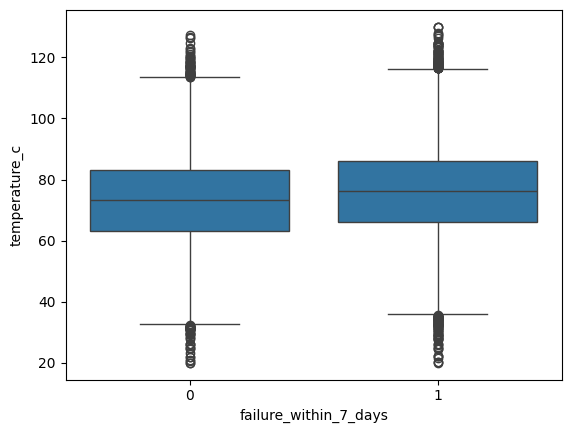

In [128]:
sns.boxplot(x='failure_within_7_days',y='temperature_c',data=df2)

In [129]:
#we do have high outliers and low outliers

In [130]:
Q1=df2['temperature_c'].quantile(0.25)
Q3=df2['temperature_c'].quantile(0.75)

In [131]:
IQR=Q3-Q1

In [132]:
upper_bound=Q3+1.5*IQR
lower_bound=Q1-1.5*IQR

In [133]:
df2[df2['temperature_c']<lower_bound].shape


(146, 20)

In [134]:
df2[df2['temperature_c']>upper_bound].shape

(151, 20)

In [135]:
df2['high_temp']=(df2['temperature_c']>upper_bound).astype(int)

In [136]:
df2['low_temp']=(df2['temperature_c']<lower_bound).astype(int)

In [137]:
df2.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,...,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.203069,90,...,7/5/2022,0,20.9,Preventive,2024,4,0,0,0,0
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.682967,720,...,10/1/2024,1,8.4,Corrective,2026,4,0,0,0,0
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.728329,720,...,4/24/2025,0,26.8,Preventive,2025,12,0,0,0,0
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.426546,365,...,3/18/2024,1,19.0,Corrective,2025,4,0,0,0,0
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.289236,365,...,8/12/2023,0,29.0,Preventive,2025,4,0,0,0,0


In [138]:
##moving on to the motor current amp

In [139]:
df2['motor_current_amp'].head()

0    104.203069
1    130.682967
2    141.728329
3    125.426546
4     60.289236
Name: motor_current_amp, dtype: float64

In [140]:
df2['motor_current_amp'].isnull().sum()

np.int64(2175)

In [141]:
df2.dropna(subset=['motor_current_amp'],inplace=True)

In [142]:
df2['motor_current_amp'].isnull().sum()

np.int64(0)

In [143]:
df2['motor_current_amp'].describe()

count    41097.000000
mean       120.033617
std         35.001014
min         10.000000
25%         96.603153
50%        120.071560
75%        143.466677
max        265.048154
Name: motor_current_amp, dtype: float64

<Axes: xlabel='failure_within_7_days', ylabel='motor_current_amp'>

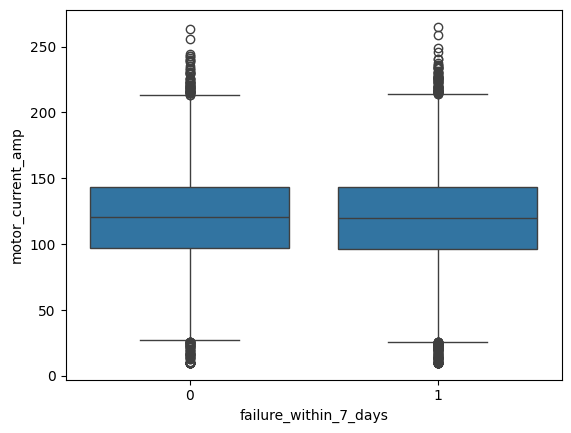

In [144]:
sns.boxplot(x='failure_within_7_days',y='motor_current_amp',data=df2)

<Axes: xlabel='plant_section', ylabel='failure_within_7_days'>

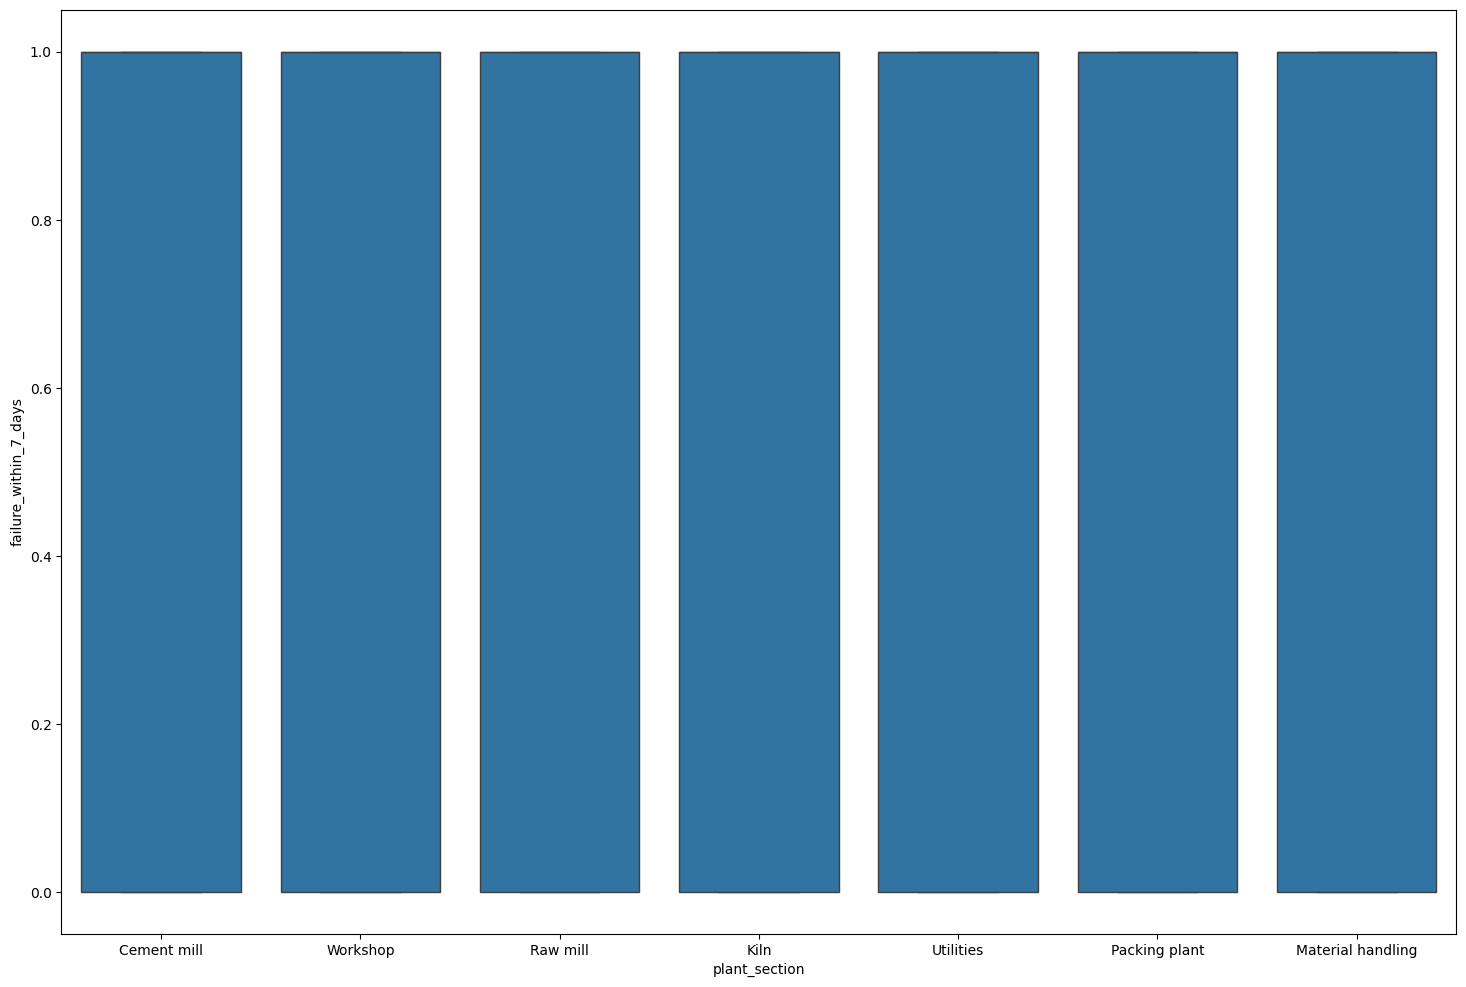

In [145]:
plt.figure(figsize=(18,12))
sns.boxplot(y='failure_within_7_days',x='plant_section',data=df2)

In [146]:
df2['motor_current_amp']=df2['motor_current_amp'].round(2)

In [147]:
df2.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,...,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.20,90,...,7/5/2022,0,20.9,Preventive,2024,4,0,0,0,0
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.68,720,...,10/1/2024,1,8.4,Corrective,2026,4,0,0,0,0
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.73,720,...,4/24/2025,0,26.8,Preventive,2025,12,0,0,0,0
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.43,365,...,3/18/2024,1,19.0,Corrective,2025,4,0,0,0,0
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.29,365,...,8/12/2023,0,29.0,Preventive,2025,4,0,0,0,0


In [148]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  last_pm_date                 41097 non-null  object 
 12  part_install_date            41097 non-null  object 
 13  failure_within_7_days

In [149]:
## looking at the root cause category

In [150]:
df2['root_cause_category'].value_counts()

root_cause_category
Contamination         5268
Wear                  5229
Lubrication           5169
Electrical Fault      5134
Overload              5121
Misalignment          5094
Fatigue               5055
Installation Error    5027
Name: count, dtype: int64

In [151]:
df2['root_cause_category']=df2['root_cause_category'].str.strip()

In [152]:
df2['last_pm_date'].value_counts()

last_pm_date
3/20/2026     58
4/8/2025      57
8/6/2025      56
5/22/2025     56
5/23/2024     54
              ..
12/27/2026     1
12/28/2026     1
12/10/2026     1
9/9/2023       1
12/29/2026     1
Name: count, Length: 1210, dtype: int64

In [153]:
df2['last_pm_date']=pd.to_datetime(df2['last_pm_date'])

In [154]:
#looking for duplicates on days that the same machines had pms

In [155]:
df2.duplicated().drop(columns=['last_pm_date']).sum()

np.int64(0)

In [156]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   plant_section                41097 non-null  object        
 1   major_equipment              41097 non-null  object        
 2   sub_equipment                41097 non-null  object        
 3   component                    41097 non-null  object        
 4   operating_hours              41097 non-null  float64       
 5   load_percent                 41097 non-null  float64       
 6   vibration_mm_s               41097 non-null  float64       
 7   temperature_c                41097 non-null  float64       
 8   motor_current_amp            41097 non-null  float64       
 9   recommended_shelf_life_days  41097 non-null  int64         
 10  root_cause_category          41097 non-null  object        
 11  last_pm_date                 41097 non-null  d

In [157]:
df2['pm_month']=df2['last_pm_date'].dt.month

In [158]:
df2['pm_year']=df2['last_pm_date'].dt.year

In [159]:
df2.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,...,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp,pm_month,pm_year
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.20,90,...,20.9,Preventive,2024,4,0,0,0,0,3,2024
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.68,720,...,8.4,Corrective,2026,4,0,0,0,0,2,2026
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.73,720,...,26.8,Preventive,2025,12,0,0,0,0,10,2025
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.43,365,...,19.0,Corrective,2025,4,0,0,0,0,1,2025
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.29,365,...,29.0,Preventive,2025,4,0,0,0,0,4,2025


In [160]:
df2.drop(columns='last_pm_date')

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,...,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp,pm_month,pm_year
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.20,90,...,20.9,Preventive,2024,4,0,0,0,0,3,2024
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.68,720,...,8.4,Corrective,2026,4,0,0,0,0,2,2026
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.73,720,...,26.8,Preventive,2025,12,0,0,0,0,10,2025
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.43,365,...,19.0,Corrective,2025,4,0,0,0,0,1,2025
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.29,365,...,29.0,Preventive,2025,4,0,0,0,0,4,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Workshop,Bearing Station,Press Fit,Motor,18.68,87.15,2.39,82.50,54.33,90,...,25.7,Corrective,2025,8,0,0,0,0,8,2025
49996,Cement mill,Ball Mill,Drive System,Belt,20.37,69.17,4.73,84.62,197.10,180,...,11.6,Corrective,2026,12,0,0,0,0,9,2026
49997,Material handling,Crusher,Drive Motor,Oil,20.44,49.94,1.99,87.13,75.63,180,...,22.3,Preventive,2024,6,0,0,0,0,3,2024
49998,Cement mill,Ball Mill,Gearbox,Gear,11.97,79.92,6.11,76.58,91.24,180,...,7.6,Corrective,2024,12,0,0,0,0,11,2024


In [161]:
df2=df2.drop(columns='last_pm_date')

In [162]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  part_install_date            41097 non-null  object 
 12  failure_within_7_days        41097 non-null  int64  
 13  days_to_next_failure 

In [163]:
df2['part_install_date'].isnull().sum()

np.int64(0)

In [164]:
df2['part_install_date'].head()

0     7/5/2022
1    10/1/2024
2    4/24/2025
3    3/18/2024
4    8/12/2023
Name: part_install_date, dtype: object

In [165]:
pd.to_datetime(df2['part_install_date'])

0       2022-07-05
1       2024-10-01
2       2025-04-24
3       2024-03-18
4       2023-08-12
           ...    
49995   2024-07-24
49996   2026-07-08
49997   2023-08-31
49998   2023-11-24
49999   2024-04-17
Name: part_install_date, Length: 41097, dtype: datetime64[ns]

In [166]:
df2['part_install_date']=pd.to_datetime(df2['part_install_date'])

In [167]:
df2['part_install_date'].head()

0   2022-07-05
1   2024-10-01
2   2025-04-24
3   2024-03-18
4   2023-08-12
Name: part_install_date, dtype: datetime64[ns]

In [168]:
df2['installation_month']=df2['part_install_date'].dt.month

In [169]:
df2['installation_year']=df2['part_install_date'].dt.year

In [170]:
df2=df2.drop(columns='part_install_date')

In [171]:
df2.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,...,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp,pm_month,pm_year,installation_month,installation_year
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.20,90,...,2024,4,0,0,0,0,3,2024,7,2022
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.68,720,...,2026,4,0,0,0,0,2,2026,10,2024
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.73,720,...,2025,12,0,0,0,0,10,2025,4,2025
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.43,365,...,2025,4,0,0,0,0,1,2025,3,2024
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.29,365,...,2025,4,0,0,0,0,4,2025,8,2023


In [172]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  failure_within_7_days        41097 non-null  int64  
 12  days_to_next_failure         41097 non-null  float64
 13  maintenance_type     

In [173]:
df2['failure_within_7_days'].value_counts()

failure_within_7_days
1    25392
0    15705
Name: count, dtype: int64

In [174]:
# no nulls present


In [175]:
df2['days_to_next_failure'].value_counts()

days_to_next_failure
0.0     609
16.6    252
14.0    252
13.8    248
16.1    241
       ... 
39.7      1
41.5      1
38.3      1
44.6      1
38.6      1
Name: count, Length: 405, dtype: int64

<Axes: xlabel='plant_section', ylabel='days_to_next_failure'>

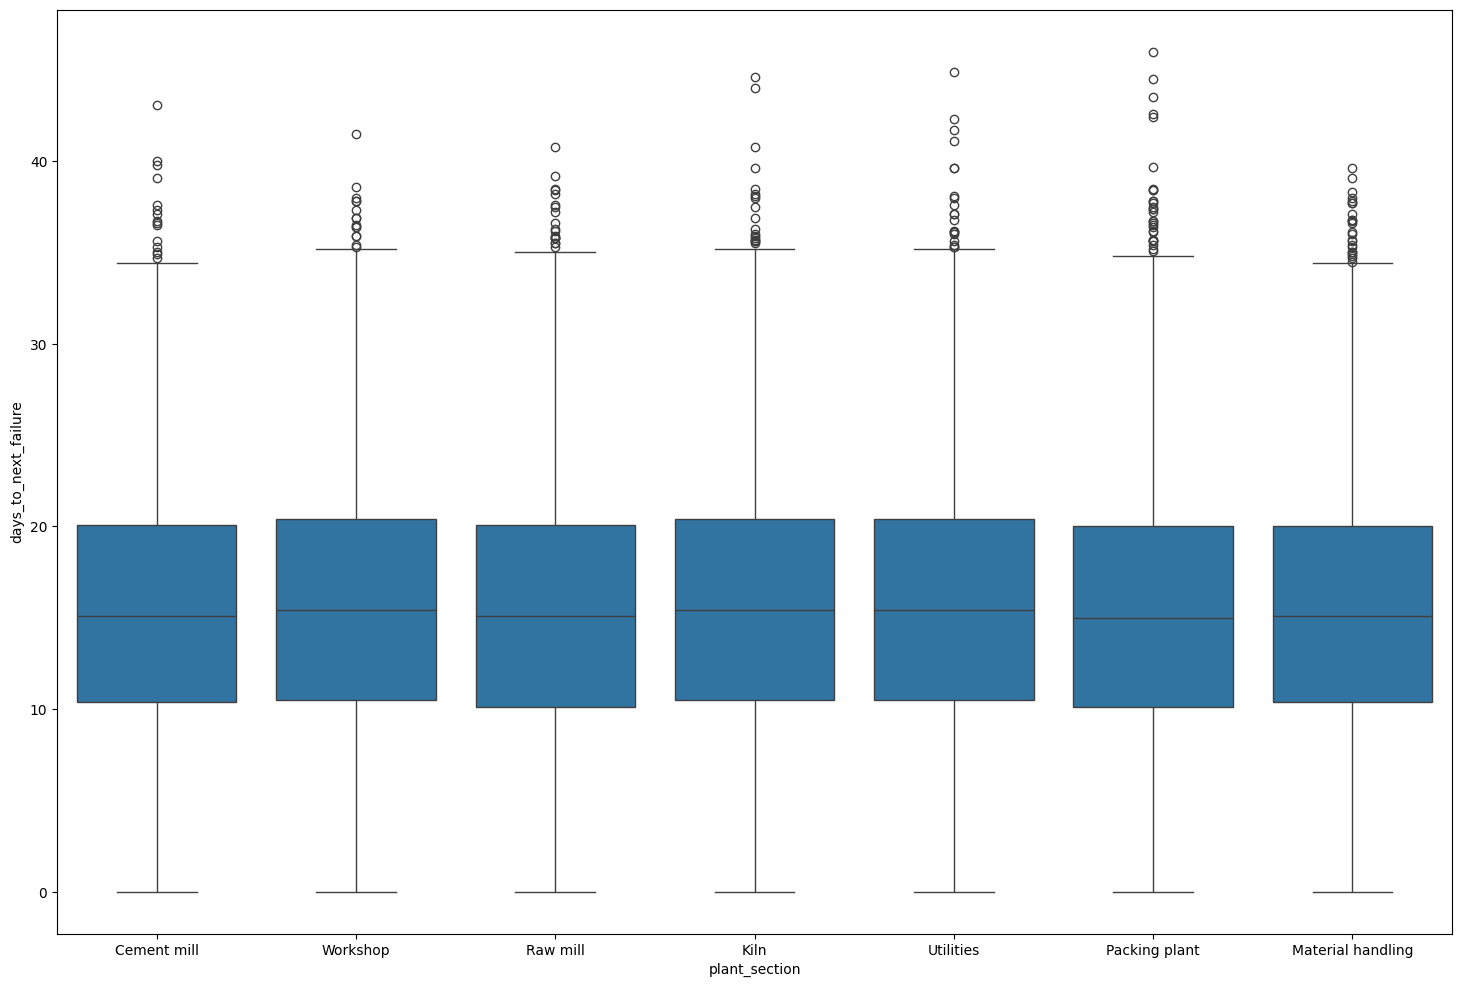

In [176]:
plt.figure(figsize=(18,12))
sns.boxplot(y='days_to_next_failure',x='plant_section',data=df2)

In [177]:
df2['maintenance_type'].head()

0    Preventive
1    Corrective
2    Preventive
3    Corrective
4    Preventive
Name: maintenance_type, dtype: object

In [178]:
df2['maintenance_type'].value_counts()

maintenance_type
Corrective         25392
Preventive         13683
Condition-Based     1206
Overhaul             816
Name: count, dtype: int64

In [179]:
df2['maintenance_type']=df2['maintenance_type'].str.strip()

In [180]:
df2['maintenance_type'].value_counts()

maintenance_type
Corrective         25392
Preventive         13683
Condition-Based     1206
Overhaul             816
Name: count, dtype: int64

In [181]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  failure_within_7_days        41097 non-null  int64  
 12  days_to_next_failure         41097 non-null  float64
 13  maintenance_type     

#### d0ne with the cleaning of the data now we do EDA

In [182]:
df2.to_csv("Cleaned_maintenance_data.csv",index=False)

## EDA

In [183]:
df2['failure_within_7_days'].value_counts()

failure_within_7_days
1    25392
0    15705
Name: count, dtype: int64

Text(0.5, 1.0, 'Failure Distribution')

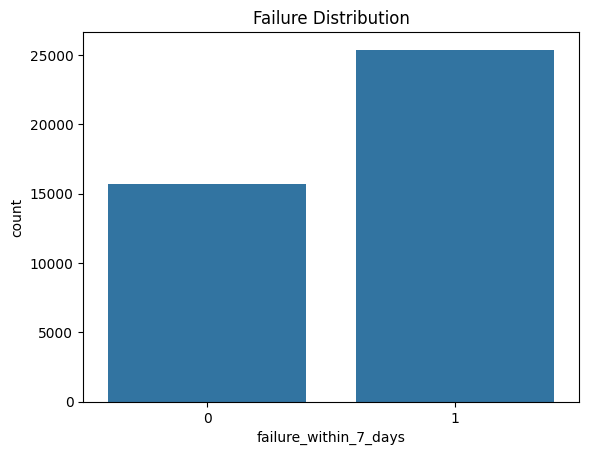

In [184]:
sns.countplot(x='failure_within_7_days',data=df2)
plt.title("Failure Distribution")

In [185]:
df2[['load_percent','vibration_mm_s','temperature_c','motor_current_amp']].describe()


,load_percent,vibration_mm_s,temperature_c,motor_current_amp
count,41097.000000,41097.000000,41097.000000,41097.000000
mean,74.988239,4.017480,75.023066,120.033608
std,14.843808,1.961118,14.923307,35.001046
min,1.080000,0.000000,20.000000,10.000000
25%,64.890000,2.660000,64.940000,96.600000
50%,75.110000,4.000000,75.010000,120.070000
75%,85.170000,5.350000,85.090000,143.470000
max,110.000000,12.440000,130.000000,265.050000


array([[<Axes: title={'center': 'load_percent'}>,
        <Axes: title={'center': 'vibration_mm_s'}>],
       [<Axes: title={'center': 'temperature_c'}>,
        <Axes: title={'center': 'motor_current_amp'}>]], dtype=object)

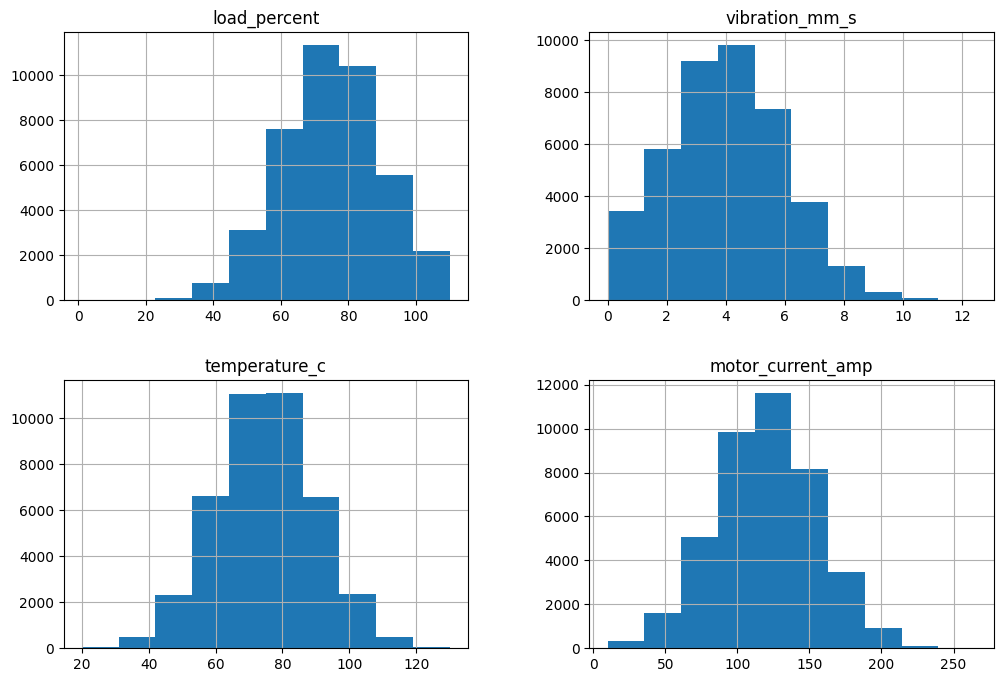

In [186]:
df2[['load_percent','vibration_mm_s','temperature_c','motor_current_amp']].hist(figsize=(12,8))

<Axes: xlabel='failure_within_7_days', ylabel='temperature_c'>

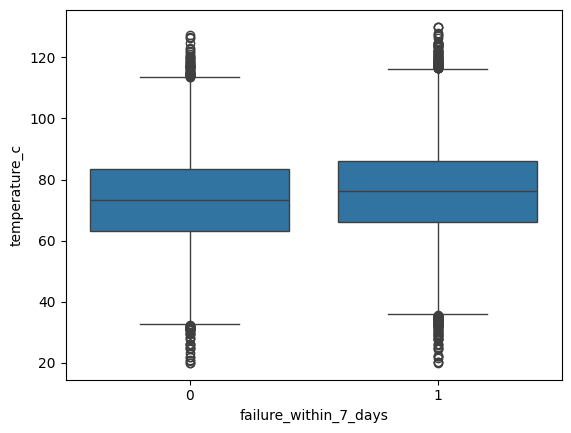

In [187]:
sns.boxplot(x='failure_within_7_days',y='temperature_c',data=df2)

<Axes: xlabel='failure_within_7_days', ylabel='vibration_mm_s'>

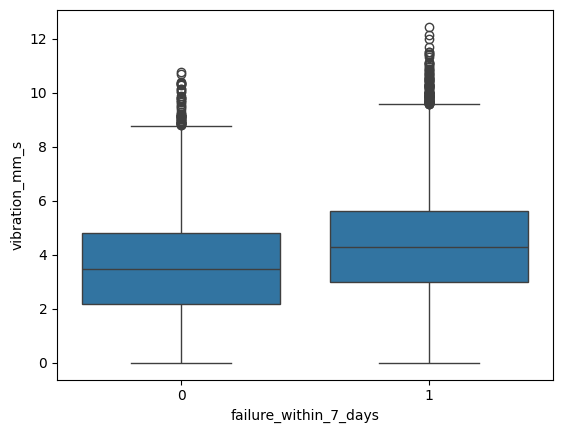

In [188]:
sns.boxplot(x='failure_within_7_days',y='vibration_mm_s',data=df2)

In [189]:
## Correlation Analysis

Text(0.5, 1.0, 'Correlation Matrix')

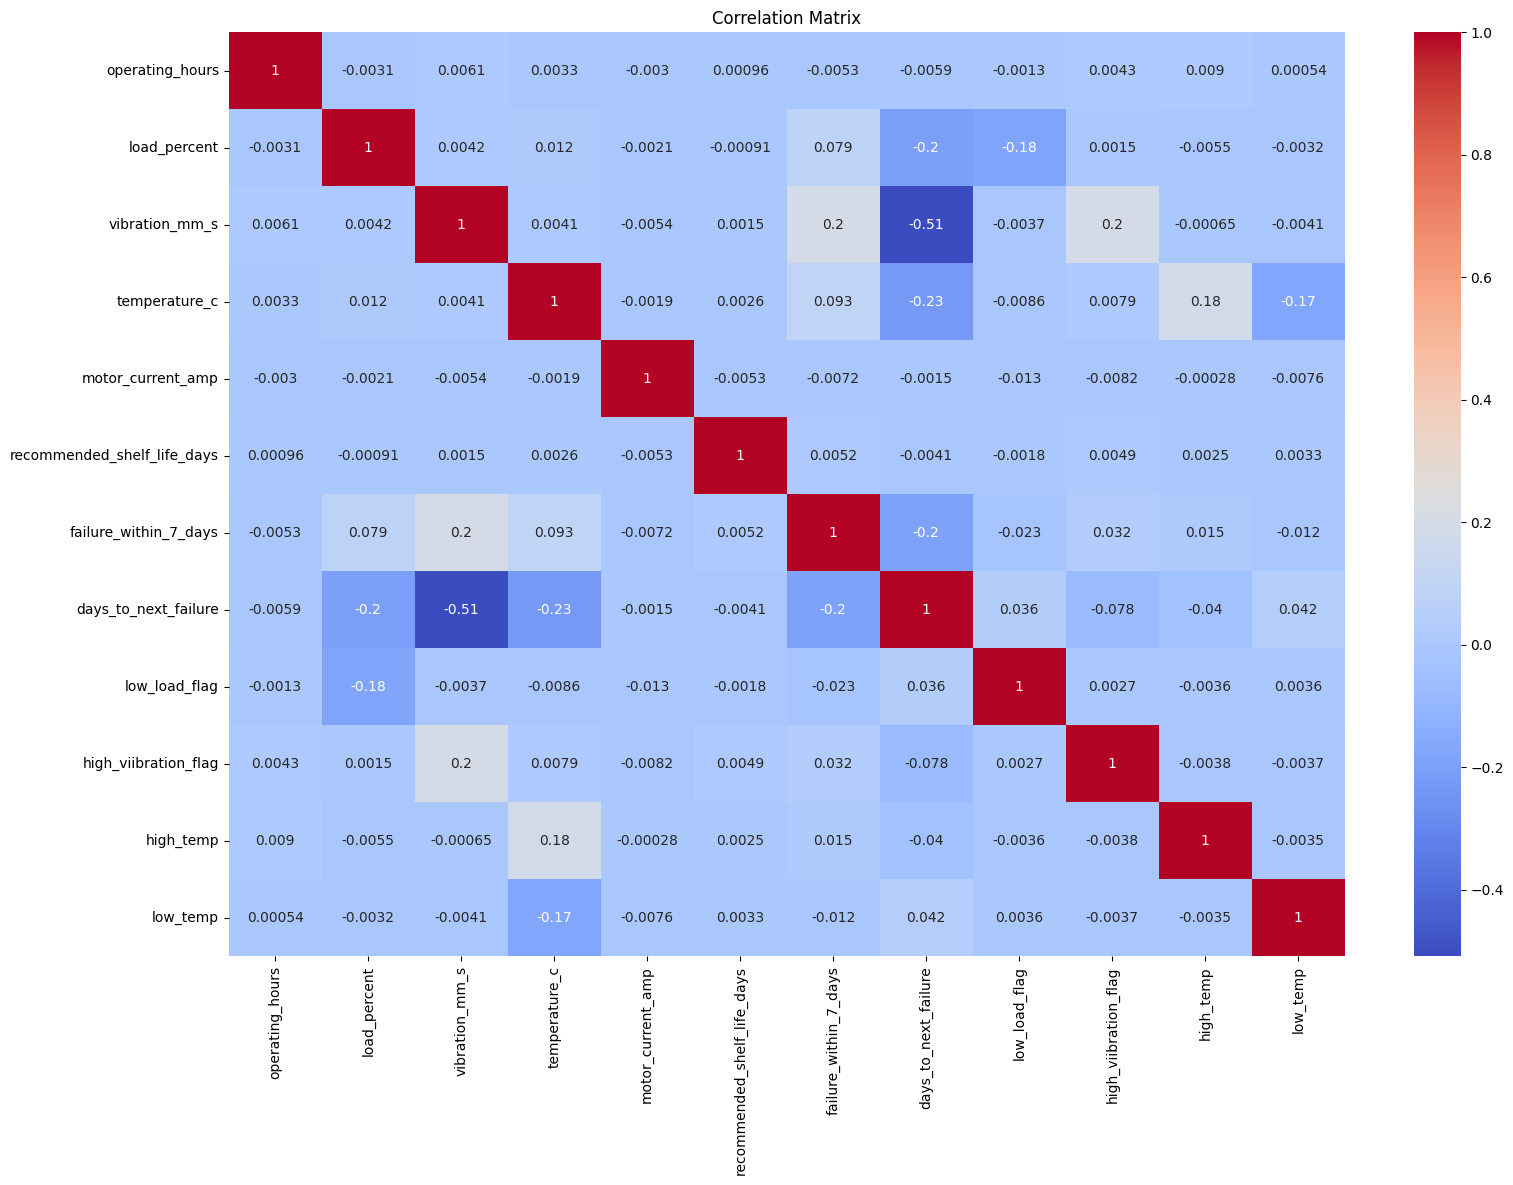

In [190]:
plt.figure(figsize=(18,12))
corr=df2.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")

<Axes: xlabel='count', ylabel='major_equipment'>

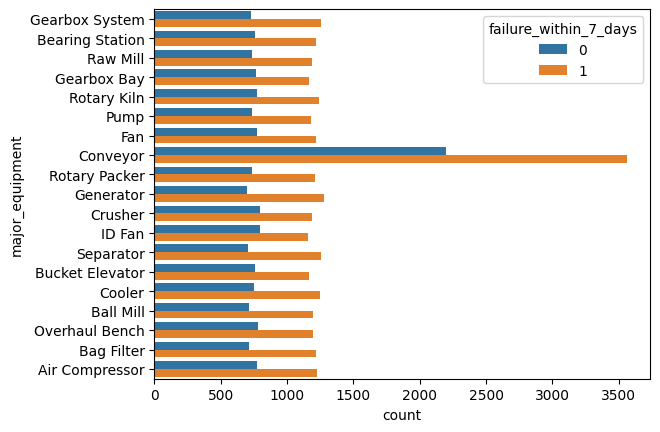

In [191]:
sns.countplot(y='major_equipment',hue='failure_within_7_days',data=df2)

<Axes: xlabel='month_of_recording', ylabel='days_to_next_failure'>

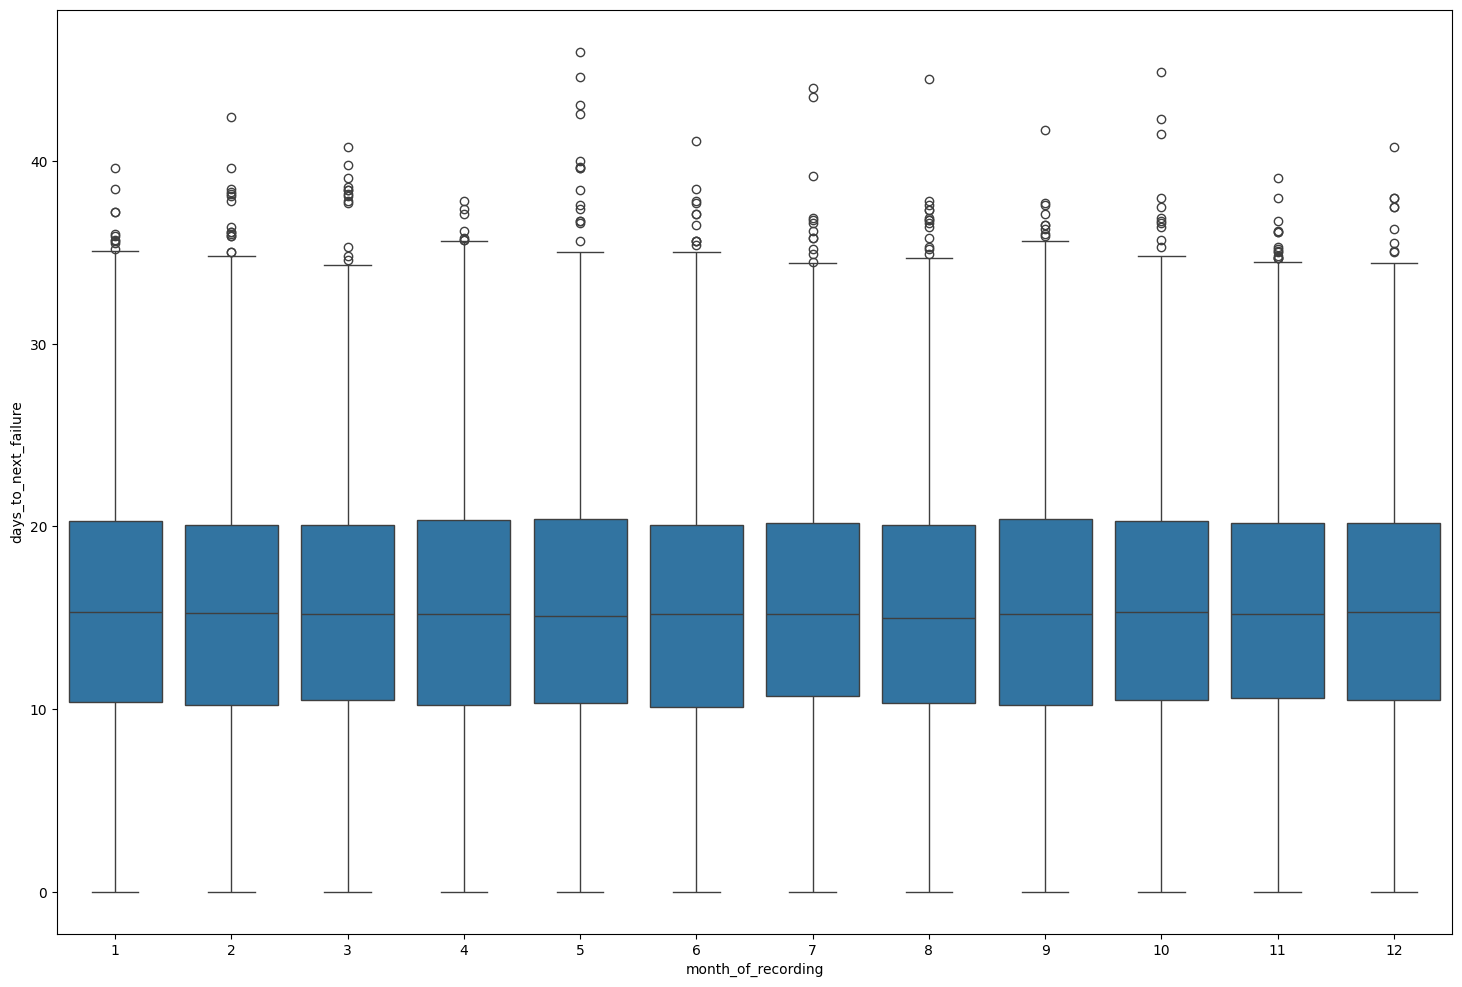

In [192]:
plt.figure(figsize=(18,12))
sns.boxplot(x='month_of_recording',y='days_to_next_failure',data=df2)

<Axes: xlabel='high_temp', ylabel='days_to_next_failure'>

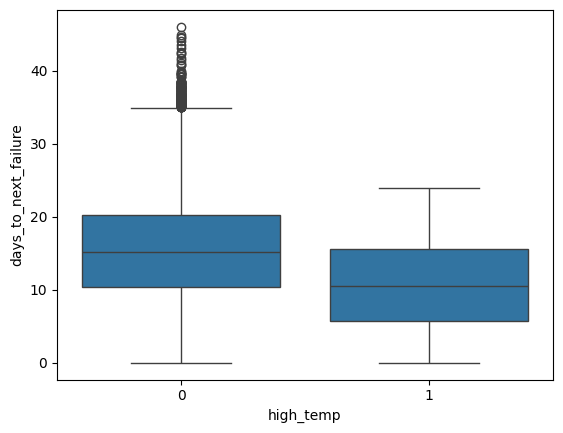

In [193]:
sns.boxplot(x='high_temp',y='days_to_next_failure',data=df2)

<Axes: xlabel='high_viibration_flag', ylabel='days_to_next_failure'>

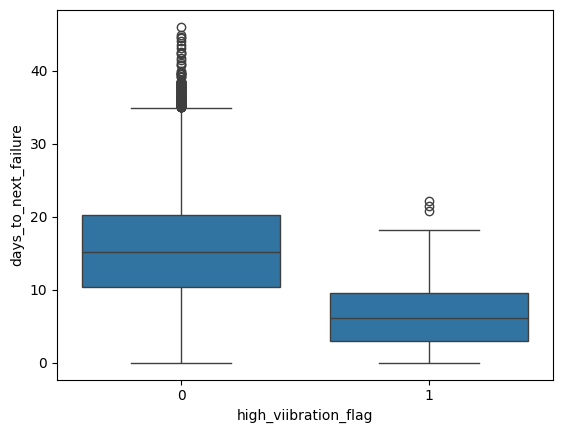

In [194]:
sns.boxplot(x='high_viibration_flag',y='days_to_next_failure',data=df2)

In [195]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  failure_within_7_days        41097 non-null  int64  
 12  days_to_next_failure         41097 non-null  float64
 13  maintenance_type     

## BUILDING THE ML MODEL FOR THE FAILURE WITHIN NEXT & DAYS

In [346]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn import linear_model
from sklearn.pipeline import Pipeline,FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.feature_selection import SelectKBest,f_classif,VarianceThreshold,f_regression
from xgboost import XGBClassifier
from category_encoders import TargetEncoder
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,accuracy_score,recall_score,precision_score,f1_score
import numpy as np

In [347]:
df2

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,...,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp,pm_month,pm_year,installation_month,installation_year
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.20,90,...,2024,4,0,0,0,0,3,2024,7,2022
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.68,720,...,2026,4,0,0,0,0,2,2026,10,2024
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.73,720,...,2025,12,0,0,0,0,10,2025,4,2025
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.43,365,...,2025,4,0,0,0,0,1,2025,3,2024
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.29,365,...,2025,4,0,0,0,0,4,2025,8,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Workshop,Bearing Station,Press Fit,Motor,18.68,87.15,2.39,82.50,54.33,90,...,2025,8,0,0,0,0,8,2025,7,2024
49996,Cement mill,Ball Mill,Drive System,Belt,20.37,69.17,4.73,84.62,197.10,180,...,2026,12,0,0,0,0,9,2026,7,2026
49997,Material handling,Crusher,Drive Motor,Oil,20.44,49.94,1.99,87.13,75.63,180,...,2024,6,0,0,0,0,3,2024,8,2023
49998,Cement mill,Ball Mill,Gearbox,Gear,11.97,79.92,6.11,76.58,91.24,180,...,2024,12,0,0,0,0,11,2024,11,2023


Text(0.5, 1.0, 'Correlation Matrix')

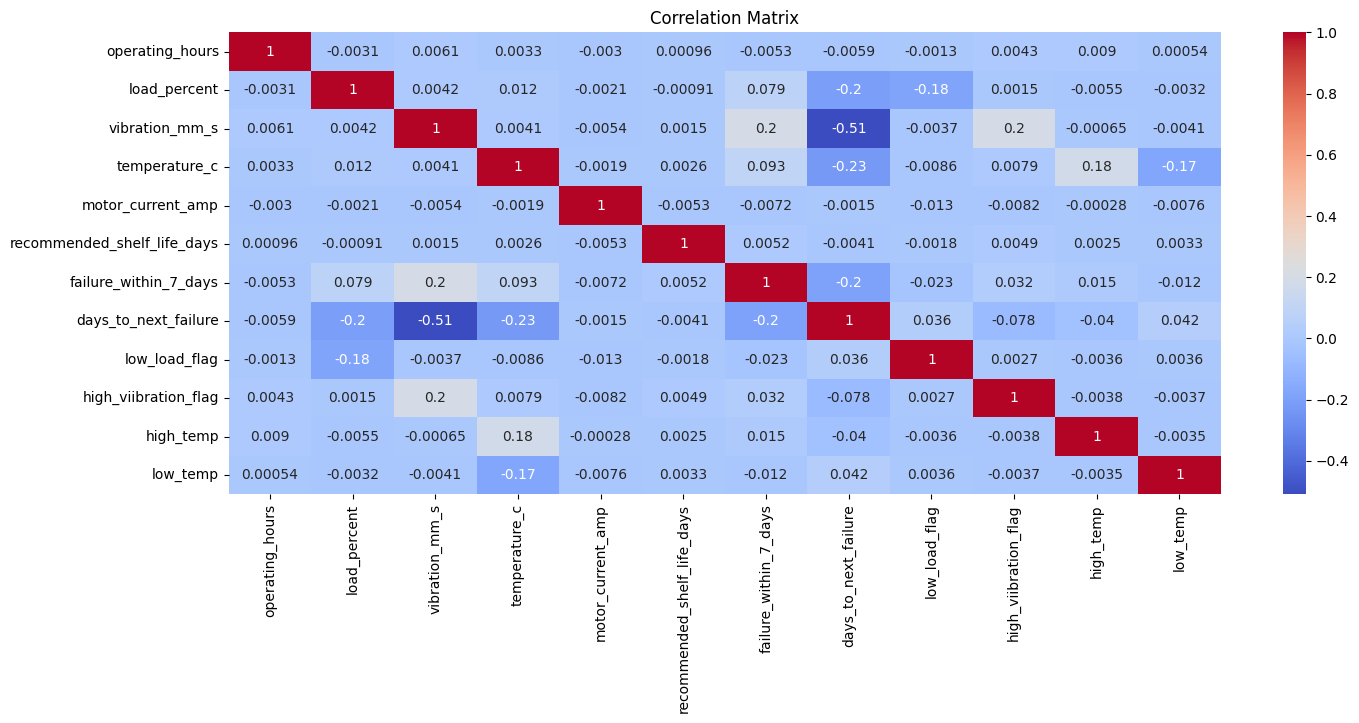

In [348]:
plt.figure(figsize=(16,6))
corr=df2.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")

In [349]:
## our main aim is to predict the failure within the net seven days

In [350]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  failure_within_7_days        41097 non-null  int64  
 12  days_to_next_failure         41097 non-null  float64
 13  maintenance_type     

In [353]:
y_failure=df2['failure_within_7_days']

In [354]:
df2['operating_hours'].describe()


count    41097.000000
mean        15.905067
std          4.758790
min          0.000000
25%         12.650000
50%         16.020000
75%         19.400000
max         24.000000
Name: operating_hours, dtype: float64

In [355]:
def categories_of_hours(hours):
 if hours>=19:
    return 'High Operating Hours'
 elif hours>=14:
    return "Average Working Hours"
 else:
    return "Low Working Hours"


In [356]:
categories_of_hours

<function __main__.categories_of_hours(hours)>

<Axes: xlabel='failure_within_7_days', ylabel='temperature_c'>

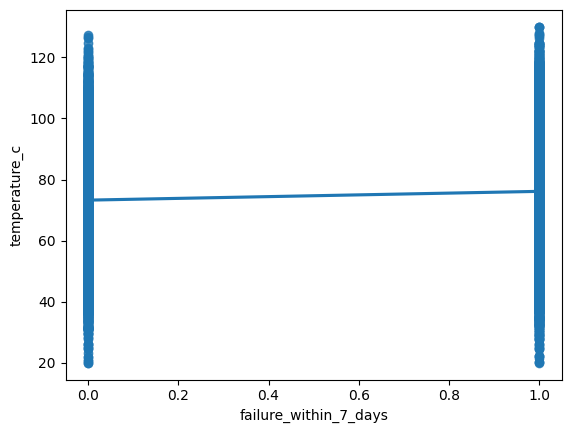

In [357]:
sns.regplot(data=df2,x="failure_within_7_days",y="temperature_c")

In [358]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  failure_within_7_days        41097 non-null  int64  
 12  days_to_next_failure         41097 non-null  float64
 13  maintenance_type     

In [360]:
y_failure.unique()

array([0, 1])

In [361]:
numericals=['vibration_mm_s',"temperature_c",'load_percent','motor_current_amp']

In [362]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  failure_within_7_days        41097 non-null  int64  
 12  days_to_next_failure         41097 non-null  float64
 13  maintenance_type     

In [363]:
categories=['plant_section']

In [364]:
df2.groupby('maintenance_type').count()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,...,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp,pm_month,pm_year,installation_month,installation_year
maintenance_type,,,,,,,,,,,,,,,,,,,,,
Condition-Based,1206,1206,1206,1206,1206,1206,1206,1206,1206,1206,...,1206,1206,1206,1206,1206,1206,1206,1206,1206,1206
Corrective,25392,25392,25392,25392,25392,25392,25392,25392,25392,25392,...,25392,25392,25392,25392,25392,25392,25392,25392,25392,25392
Overhaul,816,816,816,816,816,816,816,816,816,816,...,816,816,816,816,816,816,816,816,816,816
Preventive,13683,13683,13683,13683,13683,13683,13683,13683,13683,13683,...,13683,13683,13683,13683,13683,13683,13683,13683,13683,13683


In [365]:
df2.groupby('sub_equipment').count()

,plant_section,major_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,...,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp,pm_month,pm_year,installation_month,installation_year
sub_equipment,,,,,,,,,,,,,,,,,,,,,
Air Dryer,684,684,684,684,684,684,684,684,684,684,...,684,684,684,684,684,684,684,684,684,684
Air System,521,521,521,521,521,521,521,521,521,521,...,521,521,521,521,521,521,521,521,521,521
Alternator,652,652,652,652,652,652,652,652,652,652,...,652,652,652,652,652,652,652,652,652,652
Assembly,958,958,958,958,958,958,958,958,958,958,...,958,958,958,958,958,958,958,958,958,958
Bearings,2655,2655,2655,2655,2655,2655,2655,2655,2655,2655,...,2655,2655,2655,2655,2655,2655,2655,2655,2655,2655
Belt,1412,1412,1412,1412,1412,1412,1412,1412,1412,1412,...,1412,1412,1412,1412,1412,1412,1412,1412,1412,1412
Belt/Chain,625,625,625,625,625,625,625,625,625,625,...,625,625,625,625,625,625,625,625,625,625
Cleaning,682,682,682,682,682,682,682,682,682,682,...,682,682,682,682,682,682,682,682,682,682
Cooling,684,684,684,684,684,684,684,684,684,684,...,684,684,684,684,684,684,684,684,684,684


In [366]:
df2.groupby('component').count()

,plant_section,major_equipment,sub_equipment,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,...,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp,pm_month,pm_year,installation_month,installation_year
component,,,,,,,,,,,,,,,,,,,,,
Bearing,4619,4619,4619,4619,4619,4619,4619,4619,4619,4619,...,4619,4619,4619,4619,4619,4619,4619,4619,4619,4619
Belt,4581,4581,4581,4581,4581,4581,4581,4581,4581,4581,...,4581,4581,4581,4581,4581,4581,4581,4581,4581,4581
Coupling,4662,4662,4662,4662,4662,4662,4662,4662,4662,4662,...,4662,4662,4662,4662,4662,4662,4662,4662,4662,4662
Filter,4573,4573,4573,4573,4573,4573,4573,4573,4573,4573,...,4573,4573,4573,4573,4573,4573,4573,4573,4573,4573
Gear,4442,4442,4442,4442,4442,4442,4442,4442,4442,4442,...,4442,4442,4442,4442,4442,4442,4442,4442,4442,4442
Impeller,4567,4567,4567,4567,4567,4567,4567,4567,4567,4567,...,4567,4567,4567,4567,4567,4567,4567,4567,4567,4567
Motor,4646,4646,4646,4646,4646,4646,4646,4646,4646,4646,...,4646,4646,4646,4646,4646,4646,4646,4646,4646,4646
Oil,4487,4487,4487,4487,4487,4487,4487,4487,4487,4487,...,4487,4487,4487,4487,4487,4487,4487,4487,4487,4487
Seal,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520,...,4520,4520,4520,4520,4520,4520,4520,4520,4520,4520


In [367]:
freq=['component','sub_equipment','major_equipment']

In [368]:
x=df2[numericals+categories+freq]

In [369]:
x.head()

,vibration_mm_s,temperature_c,load_percent,motor_current_amp,plant_section,component,sub_equipment,major_equipment
0,3.19,82.62,45.66,104.20,Cement mill,Seal,Filters,Gearbox System
1,2.21,81.73,57.34,130.68,Workshop,Seal,Greasing,Bearing Station
2,2.42,72.75,83.43,141.73,Raw mill,Seal,Gearbox,Raw Mill
3,3.61,71.22,70.85,125.43,Workshop,Seal,Disassembly,Gearbox Bay
4,2.39,60.00,69.04,60.29,Kiln,Impeller,Support Rollers,Rotary Kiln


In [370]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vibration_mm_s     41097 non-null  float64
 1   temperature_c      41097 non-null  float64
 2   load_percent       41097 non-null  float64
 3   motor_current_amp  41097 non-null  float64
 4   plant_section      41097 non-null  object 
 5   component          41097 non-null  object 
 6   sub_equipment      41097 non-null  object 
 7   major_equipment    41097 non-null  object 
dtypes: float64(4), object(4)
memory usage: 2.8+ MB


## we split the data and train the data

In [371]:
train_x,test_x,train_y,test_y_failure=train_test_split(x,y_failure,test_size=0.3,random_state=42)

In [372]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28767 entries, 48321 to 19249
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vibration_mm_s     28767 non-null  float64
 1   temperature_c      28767 non-null  float64
 2   load_percent       28767 non-null  float64
 3   motor_current_amp  28767 non-null  float64
 4   plant_section      28767 non-null  object 
 5   component          28767 non-null  object 
 6   sub_equipment      28767 non-null  object 
 7   major_equipment    28767 non-null  object 
dtypes: float64(4), object(4)
memory usage: 2.0+ MB


In [373]:
preprocess=ColumnTransformer([
    ('te',TargetEncoder(),freq),
    ('oht',OneHotEncoder(drop='first'),categories),
    ('std',StandardScaler(),numericals)
])

In [374]:
feature=FeatureUnion([
    ('skt',SelectKBest(score_func=f_classif))
])
     

In [375]:
xg=XGBClassifier()
fr=RandomForestClassifier()
lr=linear_model.LogisticRegression()

In [376]:
ensemble=VotingClassifier(
    estimators=[('xg',xg),
                ('lr',lr),
                ('fr',fr)],
    voting='soft'
)


In [377]:
failure_pipeline=Pipeline([
    ('preprocess',preprocess),
    ('var',VarianceThreshold()),
    ('ensemble',ensemble)
])

In [378]:
param_grid={
    "ensemble__xg__n_estimators":[100,200],
    "ensemble__xg__max_depth":[3,5],
    "ensemble__fr__n_estimators":[50,200],
    "ensemble__fr__max_depth":[None,10],
    "ensemble__lr__C":[0.1,1,10]
}

In [379]:
scoring={
    "precision":"precision",
    "recall":"recall",
    "f1":"f1"
}

In [380]:
grid=GridSearchCV(
    estimator=failure_pipeline,
    param_grid=param_grid,
    cv=5
)

In [230]:
grid.fit(train_x,train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ing='soft'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ensemble__fr__max_depth': [None, 10], 'ensemble__fr__n_estimators': [50, 200], 'ensemble__lr__C': [0.1, 1, ...], 'ensemble__xg__max_depth': [3, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [231]:
print(grid.best_score_)
print(grid.best_params_)

0.6340943755690235
{'ensemble__fr__max_depth': 10, 'ensemble__fr__n_estimators': 200, 'ensemble__lr__C': 0.1, 'ensemble__xg__max_depth': 3, 'ensemble__xg__n_estimators': 100}


In [232]:
best_model=grid.best_estimator_

In [233]:
failure_pred=best_model.predict(test_x)

In [234]:
trial_table=test_x.copy()

In [235]:
trial_table['prediction']=failure_pred

In [236]:
trial_table.head()

,vibration_mm_s,temperature_c,load_percent,motor_current_amp,plant_section,component,sub_equipment,major_equipment,prediction
8593,5.32,82.06,61.97,96.73,Utilities,Coupling,Motor,Air Compressor,1
42526,6.36,83.65,63.39,159.64,Kiln,Coupling,Bearings,ID Fan,1
47950,2.47,86.58,80.82,30.10,Packing plant,Gear,Belt,Conveyor,1
12437,6.02,52.06,64.76,114.06,Workshop,Seal,Press Fit,Bearing Station,1
17048,6.86,87.83,53.43,85.92,Material handling,Bearing,Head Pulley,Bucket Elevator,1


In [383]:
print(classification_report(test_y_failure,failure_pred))

              precision    recall  f1-score   support

           0       0.58      0.23      0.33      4714
           1       0.65      0.90      0.76      7616

    accuracy                           0.64     12330
   macro avg       0.62      0.57      0.55     12330
weighted avg       0.63      0.64      0.59     12330



## we need to do threshold Tuning

In [238]:
y_prob=best_model.predict_proba(test_x)[:,1]

In [239]:
y_prob

array([0.6935137 , 0.67304523, 0.60050651, ..., 0.65673098, 0.57714529,
       0.52734817])

In [ ]:
for t in [0.5,0.4,0.3,0.2]:
    preds=(y_prob>t).astype(int)
    print("\nThreshold:",t)
    print(classification_report(test_y_failure,preds))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.58      0.23      0.33      4714
           1       0.65      0.90      0.76      7616

    accuracy                           0.64     12330
   macro avg       0.62      0.57      0.55     12330
weighted avg       0.63      0.64      0.59     12330


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.63      0.04      0.08      4714
           1       0.62      0.99      0.76      7616

    accuracy                           0.62     12330
   macro avg       0.63      0.51      0.42     12330
weighted avg       0.63      0.62      0.50     12330


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.82      0.00      0.00      4714
           1       0.62      1.00      0.76      7616

    accuracy                           0.62     12330
   macro avg       0.72      0.50      0.38     12330
weighted avg       0.69   

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

## points to note

In [ ]:
for t in [0.7,0.6,0.5,0.4]:
    preds=(y_prob>t).astype(int)
    print("\nThreshold:",t)
    print(classification_report(test_y_failure,preds))


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.43      0.84      0.57      4714
           1       0.76      0.30      0.43      7616

    accuracy                           0.51     12330
   macro avg       0.59      0.57      0.50     12330
weighted avg       0.63      0.51      0.48     12330


Threshold: 0.6
              precision    recall  f1-score   support

           0       0.50      0.55      0.52      4714
           1       0.70      0.66      0.68      7616

    accuracy                           0.61     12330
   macro avg       0.60      0.60      0.60     12330
weighted avg       0.62      0.61      0.62     12330


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.58      0.23      0.33      4714
           1       0.65      0.90      0.76      7616

    accuracy                           0.64     12330
   macro avg       0.62      0.57      0.55     12330
weighted avg       0.63   

In [242]:
threshold=0.6

In [243]:
joblib.dump(threshold,"threshold.pkl")

['threshold.pkl']

In [244]:
joblib.dump(best_model,"failure_detection.pkl")

['failure_detection.pkl']

## Moving on to the second model of predicting the number of days it will take for failure

In [245]:
df_cleaned=pd.read_csv(r"C:\Users\user\Desktop\Maintenance Project\Cleaned_maintenance_data.csv")

In [246]:
df_cleaned.head()

,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,...,year_of_recording,month_of_recording,low_load_flag,high_viibration_flag,high_temp,low_temp,pm_month,pm_year,installation_month,installation_year
0,Cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.20,90,...,2024,4,0,0,0,0,3,2024,7,2022
1,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.68,720,...,2026,4,0,0,0,0,2,2026,10,2024
2,Raw mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.73,720,...,2025,12,0,0,0,0,10,2025,4,2025
3,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.43,365,...,2025,4,0,0,0,0,1,2025,3,2024
4,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.29,365,...,2025,4,0,0,0,0,4,2025,8,2023


In [247]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41097 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   plant_section                41097 non-null  object 
 1   major_equipment              41097 non-null  object 
 2   sub_equipment                41097 non-null  object 
 3   component                    41097 non-null  object 
 4   operating_hours              41097 non-null  float64
 5   load_percent                 41097 non-null  float64
 6   vibration_mm_s               41097 non-null  float64
 7   temperature_c                41097 non-null  float64
 8   motor_current_amp            41097 non-null  float64
 9   recommended_shelf_life_days  41097 non-null  int64  
 10  root_cause_category          41097 non-null  object 
 11  failure_within_7_days        41097 non-null  int64  
 12  days_to_next_failure         41097 non-null  float64
 13  maintenance_type     

In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         50000 non-null  datetime64[ns]
 1   plant_section                50000 non-null  object        
 2   major_equipment              50000 non-null  object        
 3   sub_equipment                50000 non-null  object        
 4   component                    50000 non-null  object        
 5   operating_hours              50000 non-null  float64       
 6   load_percent                 50000 non-null  object        
 7   vibration_mm_s               46059 non-null  float64       
 8   temperature_c                47101 non-null  object        
 9   motor_current_amp            47460 non-null  float64       
 10  recommended_shelf_life_days  50000 non-null  int64         
 11  root_cause_category          50000 non-nu

In [249]:
df_nextday=df.copy()

In [250]:
df_nextday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         50000 non-null  datetime64[ns]
 1   plant_section                50000 non-null  object        
 2   major_equipment              50000 non-null  object        
 3   sub_equipment                50000 non-null  object        
 4   component                    50000 non-null  object        
 5   operating_hours              50000 non-null  float64       
 6   load_percent                 50000 non-null  object        
 7   vibration_mm_s               46059 non-null  float64       
 8   temperature_c                47101 non-null  object        
 9   motor_current_amp            47460 non-null  float64       
 10  recommended_shelf_life_days  50000 non-null  int64         
 11  root_cause_category          50000 non-nu

In [251]:
df_nextday.dropna(inplace=True)

In [252]:
df_nextday.info()


<class 'pandas.core.frame.DataFrame'>
Index: 41215 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         41215 non-null  datetime64[ns]
 1   plant_section                41215 non-null  object        
 2   major_equipment              41215 non-null  object        
 3   sub_equipment                41215 non-null  object        
 4   component                    41215 non-null  object        
 5   operating_hours              41215 non-null  float64       
 6   load_percent                 41215 non-null  object        
 7   vibration_mm_s               41215 non-null  float64       
 8   temperature_c                41215 non-null  object        
 9   motor_current_amp            41215 non-null  float64       
 10  recommended_shelf_life_days  41215 non-null  int64         
 11  root_cause_category          41215 non-null  o

Text(0.5, 1.0, 'Correlation Matrix')

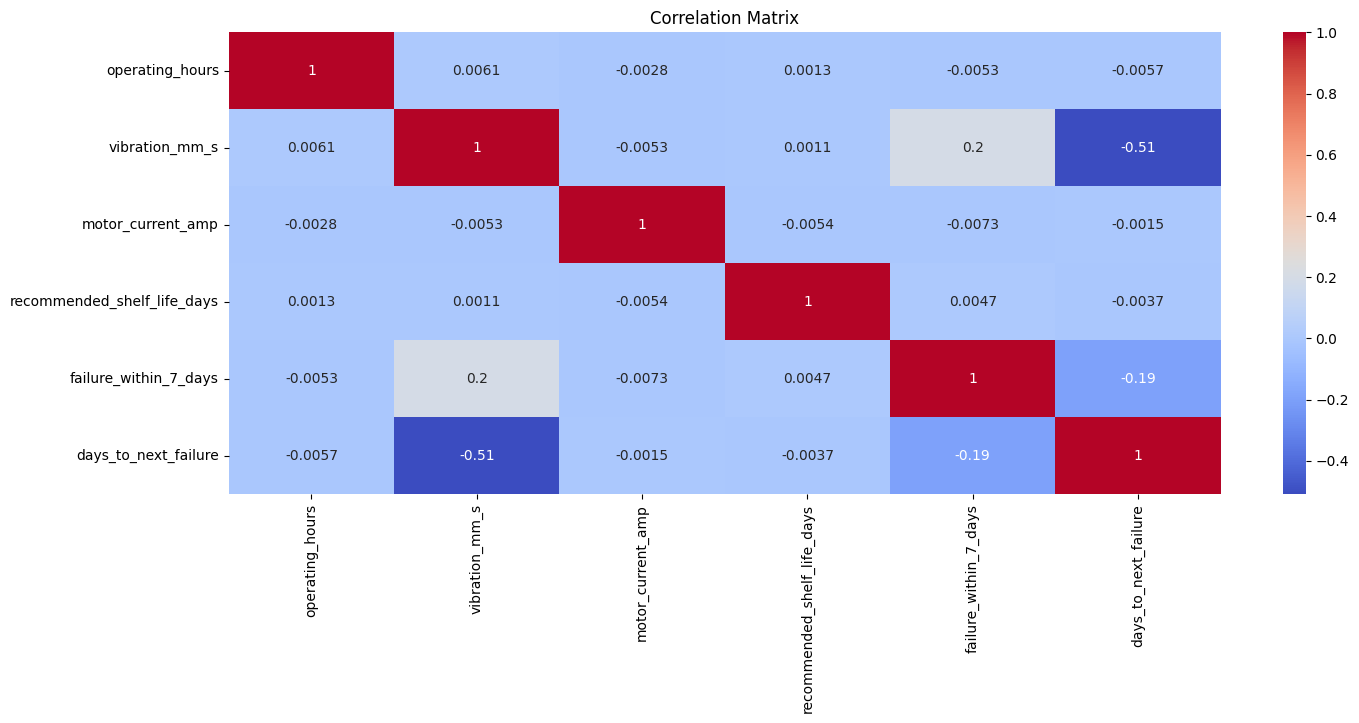

In [253]:
plt.figure(figsize=(16,6))
corr=df_nextday.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")

In [254]:
freq2=['component','sub_equipment','major_equipment',]

In [255]:
categories2=['plant_section','maintenance_type']

In [256]:
load_percent=df2['load_percent']

In [257]:
numericals2=['vibration_mm_s', 'temperature_c', 'load_percent', 'motor_current_amp','operating_hours']

In [258]:
numericals2

['vibration_mm_s',
 'temperature_c',
 'load_percent',
 'motor_current_amp',
 'operating_hours']

In [259]:
df.head()

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4


In [260]:
df_nextday.head()

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.560116,45.66035665,3.192245,82.61548865,104.203069,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.537198,57.34295024,2.210943,81.7327296797816C,130.682967,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.058052,83.42828683,2.421139,72.75185086,141.728329,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.690068,70.85487452,3.614778,71.2237025,125.426546,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.684487,69.0366604,2.392986,59.99660913,60.289236,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4


In [261]:
df_nextday.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41215 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         41215 non-null  datetime64[ns]
 1   plant_section                41215 non-null  object        
 2   major_equipment              41215 non-null  object        
 3   sub_equipment                41215 non-null  object        
 4   component                    41215 non-null  object        
 5   operating_hours              41215 non-null  float64       
 6   load_percent                 41215 non-null  object        
 7   vibration_mm_s               41215 non-null  float64       
 8   temperature_c                41215 non-null  object        
 9   motor_current_amp            41215 non-null  float64       
 10  recommended_shelf_life_days  41215 non-null  int64         
 11  root_cause_category          41215 non-null  o

In [262]:
df_nextday.loc[df_nextday['load_percent'].astype(str).str.contains(r'[^0-9.-]',regex=True),'load_percent'].unique()

array(['87.12%', '96.52%', '86.01%', ..., '99.44%', '85.14%', '94.38%'],
      dtype=object)

In [263]:
df_nextday['load_percent'].str.replace('%','')

0        45.66035665
1        57.34295024
2        83.42828683
3        70.85487452
4         69.0366604
            ...     
49995    87.15140747
49996    69.17129487
49997          49.94
49998    79.92015937
49999    67.92052321
Name: load_percent, Length: 41215, dtype: object

In [264]:
df_nextday['load_percent']=df_nextday['load_percent'].str.replace('%','')

In [265]:
pd.to_numeric(df_nextday['load_percent'])

0        45.660357
1        57.342950
2        83.428287
3        70.854875
4        69.036660
           ...    
49995    87.151407
49996    69.171295
49997    49.940000
49998    79.920159
49999    67.920523
Name: load_percent, Length: 41215, dtype: float64

In [266]:
df_nextday['load_percent']=pd.to_numeric(df_nextday['load_percent'])

In [267]:
df_nextday['load_percent']=df_nextday['load_percent'].round(2)

In [268]:
df_nextday.loc[df_nextday['temperature_c'].astype(str).str.contains(r'[^0-9.-]',regex=True),'temperature_c'].unique()

array(['81.7327296797816C', '70.66728000715405C', '88.13068082227882C',
       ..., '80.82717891091686C', '67.99118914359606C',
       '61.94149383015307C'], dtype=object)

In [269]:
df_nextday['temperature_c']=df_nextday['temperature_c'].str.replace('C','')

In [270]:
df_nextday['temperature_c']=pd.to_numeric(df_nextday['temperature_c'],errors='coerce')

In [271]:
df_nextday.isnull().sum()

date                             0
plant_section                    0
major_equipment                  0
sub_equipment                    0
component                        0
operating_hours                  0
load_percent                     0
vibration_mm_s                   0
temperature_c                  118
motor_current_amp                0
recommended_shelf_life_days      0
root_cause_category              0
last_pm_date                     0
part_install_date                0
failure_within_7_days            0
days_to_next_failure             0
maintenance_type                 0
year_of_recording                0
month_of_recording               0
dtype: int64

In [272]:
df_nextday.dropna(subset='temperature_c',inplace=True)

In [273]:
df_nextday['temperature_c']=df_nextday['temperature_c'].round(2)

In [274]:
df_nextday.round(2)

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.20,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.68,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.73,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.43,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.29,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-08-30,workshop,Bearing Station,Press Fit,Motor,18.68,87.15,2.39,82.50,54.33,90,Overload,8/27/2025,7/24/2024,1,25.7,Corrective,2025,8
49996,2026-12-19,Cement Mill,Ball Mill,Drive System,Belt,20.37,69.17,4.73,84.62,197.10,180,Overload,9/2/2026,7/8/2026,1,11.6,Corrective,2026,12
49997,2024-06-24,Material Handling,Crusher,Drive Motor,Oil,20.44,49.94,1.99,87.13,75.63,180,Lubrication,3/10/2024,8/31/2023,0,22.3,Preventive,2024,6
49998,2024-12-05,Cement Mill,Ball Mill,Gearbox,Gear,11.97,79.92,6.11,76.58,91.24,180,Contamination,11/3/2024,11/24/2023,1,7.6,Corrective,2024,12


In [275]:
df_nextday=df_nextday.round(2)

Text(0.5, 1.0, 'Correlation Matrix')

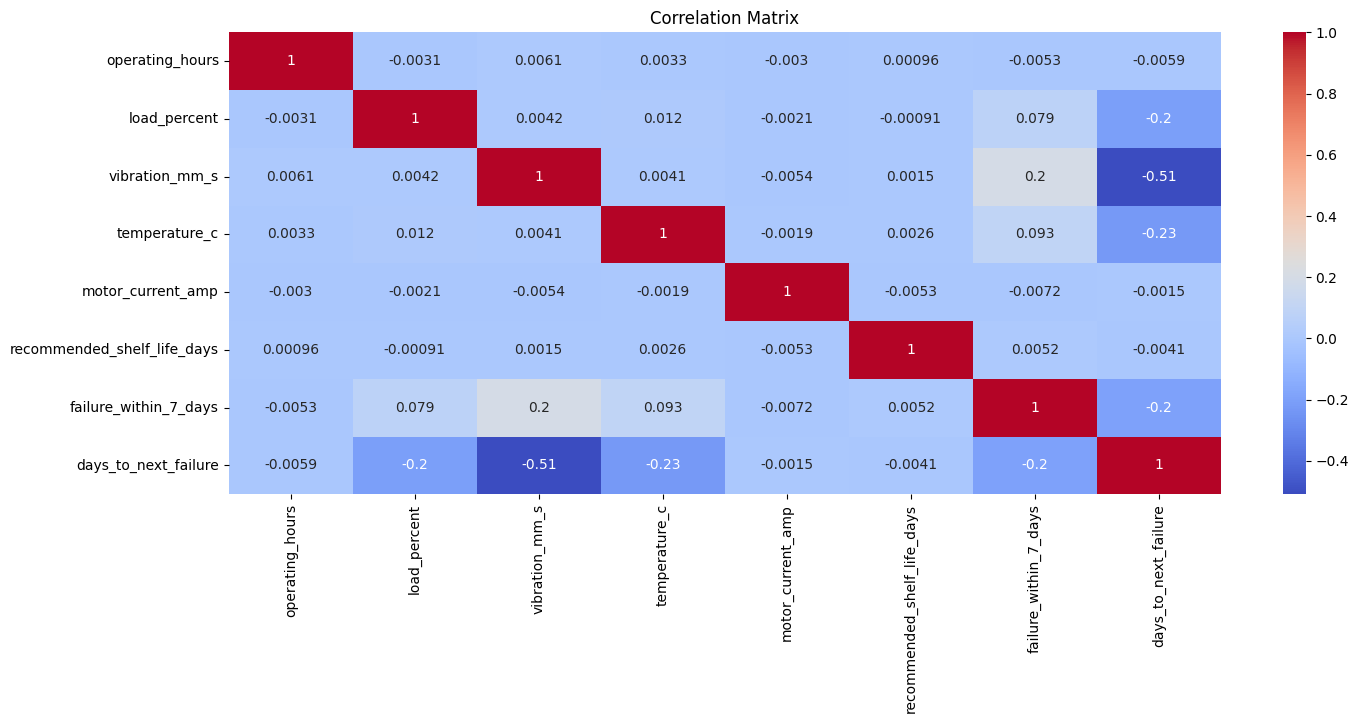

In [276]:
plt.figure(figsize=(16,6))
corr=df_nextday.select_dtypes(include=['float64','int64']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")

In [385]:
y_days=df_nextday['days_to_next_failure']

In [386]:
x=df_nextday[freq2+categories2+numericals2]

In [387]:
x.head()

,component,sub_equipment,major_equipment,plant_section,maintenance_type,vibration_mm_s,temperature_c,load_percent,motor_current_amp,operating_hours
0,Seal,Filters,Gearbox System,cement mill,Preventive,3.19,82.62,45.66,104.20,22.56
1,Seal,Greasing,Bearing Station,Workshop,Corrective,2.21,81.73,57.34,130.68,15.54
2,Seal,Gearbox,Raw Mill,Raw Mill,Preventive,2.42,72.75,83.43,141.73,15.06
3,Seal,Disassembly,Gearbox Bay,Workshop,Corrective,3.61,71.22,70.85,125.43,15.69
4,Impeller,Support Rollers,Rotary Kiln,Kiln,Preventive,2.39,60.00,69.04,60.29,20.68


## starting with feature engineering

In [388]:
train_x,test_x,train_y,test_y_days=train_test_split(x,y_days,test_size=0.3,random_state=42)

In [389]:
train_x.head()

,component,sub_equipment,major_equipment,plant_section,maintenance_type,vibration_mm_s,temperature_c,load_percent,motor_current_amp,operating_hours
48321,Oil,Belt,Conveyor,Packing Plant,Corrective,4.97,96.80,84.51,77.92,17.99
37343,Belt,Gearbox,Ball Mill,Cement Mill,Condition-Based,4.52,73.86,76.38,142.70,15.45
15230,Filter,Fans,Cooler,Kiln,Preventive,4.24,84.85,65.89,87.04,24.00
19176,Belt,Bearings,Raw Mill,Raw Mill,Corrective,4.17,65.77,58.93,31.12,13.44
41372,Bearing,Filters,Air Compressor,Utilities,Preventive,3.45,72.34,69.99,35.96,9.89


In [390]:
preprocess=ColumnTransformer([
    ('te',TargetEncoder(),freq2),
    ('oht',OneHotEncoder(drop='first'),categories2),
    ('std',StandardScaler(),numericals2)
])

In [391]:
features=FeatureUnion([
    ('skt',SelectKBest(score_func=f_regression))
])

In [392]:
model=linear_model.LinearRegression()

In [393]:
## no need to ensemble as we are only using linear regression

In [394]:
nextfailure_pipeline=Pipeline([
    ('preprocess',preprocess),
    ('features',features),
    ('model',model)
])
    

In [395]:
param_grid={
    "features__skt__k":[5,8,10,'all'],
    "model__fit_intercept":[True,False],
    "model__positive":[True,False]
}

In [396]:
grid=GridSearchCV(
    estimator=nextfailure_pipeline,
    param_grid=param_grid,
    cv=5
)

In [397]:
grid.fit(train_x,train_y)

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
40 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\AppData\Lo

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'features__skt__k': [5, 8, ...], 'model__fit_intercept': [True, False], 'model__positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is d

In [398]:
print(grid.best_score_)
print(grid.best_params_)

0.3612012402512547
{'features__skt__k': 10, 'model__fit_intercept': False, 'model__positive': False}


In [291]:
best_model=grid.best_estimator_

In [292]:
y_pred=best_model.predict(test_x).round(2)

In [293]:
y_pred

array([13.15, 10.89, 17.22, ..., 13.62, 17.39, 17.34])

In [294]:
new_x=test_x.copy()

In [295]:
new_x['days_to_failure']=y_pred

In [296]:
new_x.head(50)

,component,sub_equipment,major_equipment,plant_section,maintenance_type,vibration_mm_s,temperature_c,load_percent,motor_current_amp,operating_hours,days_to_failure
8593,Coupling,Motor,Air Compressor,Utilities,Corrective,5.32,82.06,61.97,96.73,22.05,13.15
42526,Coupling,Bearings,ID Fan,Kiln,Corrective,6.36,83.65,63.39,159.64,17.07,10.89
47950,Gear,Belt,Conveyor,packing plant,Preventive,2.47,86.58,80.82,30.10,8.37,17.22
12437,Seal,Press Fit,Bearing Station,Workshop,Corrective,6.02,52.06,64.76,114.06,18.80,14.73
17048,Bearing,Head Pulley,Bucket Elevator,Material Handling,Corrective,6.86,87.83,53.43,85.92,8.66,10.56
7943,Coupling,Disassembly,Gearbox Bay,Workshop,Corrective,5.05,63.66,58.67,129.70,5.59,15.65
38452,Coupling,Motor,ID Fan,Kiln,Preventive,0.00,74.78,64.08,67.35,14.05,24.20
24666,Gear,General,Fan,Raw Mill,Corrective,7.83,89.09,85.59,181.78,20.46,5.92
32457,Coupling,Alternator,Generator,Utilities,Corrective,2.10,56.99,88.50,78.35,15.27,18.77
11646,Impeller,Bearings,Separator,Cement Mill,Corrective,5.93,86.54,57.93,134.51,20.28,11.84


In [399]:
r2_score(test_y_days,y_pred)
mean_absolute_error(test_y_days,y_pred)
mean_squared_error(test_y_days,y_pred)

print("R2_Score:",r2_score(test_y_days,y_pred))
print("MAE:",mean_absolute_error(test_y_days,y_pred))
print("MSE:",mean_squared_error(test_y_days,y_pred))

R2_Score: 0.35375436009956196
MAE: 4.599540145985402
MSE: 33.298433779399836


In [298]:
joblib.dump(best_model,'daysto_next_failure.pkl')

['daysto_next_failure.pkl']

## To the third and final Model that Helps Predict the type of maintenance that can be done

In [299]:
df_nextday.head()

,date,plant_section,major_equipment,sub_equipment,component,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,root_cause_category,last_pm_date,part_install_date,failure_within_7_days,days_to_next_failure,maintenance_type,year_of_recording,month_of_recording
0,2024-04-07,cement mill,Gearbox System,Filters,Seal,22.56,45.66,3.19,82.62,104.20,90,Installation Error,3/4/2024,7/5/2022,0,20.9,Preventive,2024,4
1,2026-04-27,Workshop,Bearing Station,Greasing,Seal,15.54,57.34,2.21,81.73,130.68,720,Fatigue,2/23/2026,10/1/2024,1,8.4,Corrective,2026,4
2,2025-12-17,Raw Mill,Raw Mill,Gearbox,Seal,15.06,83.43,2.42,72.75,141.73,720,Contamination,10/13/2025,4/24/2025,0,26.8,Preventive,2025,12
3,2025-04-25,Workshop,Gearbox Bay,Disassembly,Seal,15.69,70.85,3.61,71.22,125.43,365,Misalignment,1/5/2025,3/18/2024,1,19.0,Corrective,2025,4
4,2025-04-19,Kiln,Rotary Kiln,Support Rollers,Impeller,20.68,69.04,2.39,60.00,60.29,365,Fatigue,4/11/2025,8/12/2023,0,29.0,Preventive,2025,4


In [300]:
df_maintenance_type=df_nextday.copy()

In [301]:
y=df_maintenance_type['maintenance_type']

In [302]:
cats3=['plant_section','major_equipment','sub_equipment','component','root_cause_category']

In [303]:
nums3=['operating_hours','load_percent','vibration_mm_s','temperature_c','motor_current_amp','recommended_shelf_life_days','days_to_next_failure']

In [304]:
x=df_maintenance_type[cats3+nums3]

In [305]:
train_x,test_x,train_y,test_y=train_test_split(x,y,test_size=0.3,random_state=42)

In [306]:
train_x.head()

,plant_section,major_equipment,sub_equipment,component,root_cause_category,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,days_to_next_failure
48321,Packing Plant,Conveyor,Belt,Oil,Fatigue,17.99,84.51,4.97,96.80,77.92,365,2.4
37343,Cement Mill,Ball Mill,Gearbox,Belt,Lubrication,15.45,76.38,4.52,73.86,142.70,540,7.8
15230,Kiln,Cooler,Fans,Filter,Lubrication,24.00,65.89,4.24,84.85,87.04,365,23.4
19176,Raw Mill,Raw Mill,Bearings,Belt,Wear,13.44,58.93,4.17,65.77,31.12,365,17.3
41372,Utilities,Air Compressor,Filters,Bearing,Lubrication,9.89,69.99,3.45,72.34,35.96,540,3.5


In [307]:
preprocess=ColumnTransformer([
    ('oht',OneHotEncoder(drop="first"),cats3),
    ('std',StandardScaler(),nums3)
])

In [308]:
features=FeatureUnion([
    ('skt',SelectKBest(score_func=f_classif))
])

In [309]:
lr=linear_model.LogisticRegression(class_weight='balanced')
xg=XGBClassifier()
rf=RandomForestClassifier(class_weight='balanced')

In [310]:
ensemble=VotingClassifier(
    estimators=[('lr',lr),
                ('xg',xg),
                ('rf',rf)],
    voting='soft'
)

In [311]:
maintenance_type_pipeline=Pipeline([
    ('preprocess',preprocess),
    ('features',features),
    ('ensemble',ensemble)
])

In [312]:
param_grid={
    "features__skt__k":[5,8,10,'all'],
    "ensemble__xg__n_estimators":[100],
    "ensemble__xg__max_depth":[3,5],
    "ensemble__rf__n_estimators":[100],
    "ensemble__rf__max_depth":[None],
    "ensemble__lr__C":[1]
}

In [313]:
scoring={
    "f1_macro":"f1_macro",
    "recall_macro":"recall_macro",
    "precision_macro":"precision_macro"
}

In [314]:
grid=GridSearchCV(
    param_grid=param_grid,
    estimator=maintenance_type_pipeline,
    cv=4,
    scoring=scoring,
    refit="f1_macro",
    n_jobs=-1
)

In [315]:
grid.fit(train_x,train_y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ing='soft'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ensemble__lr__C': [1], 'ensemble__rf__max_depth': [None], 'ensemble__rf__n_estimators': [100], 'ensemble__xg__max_depth': [3, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: i

In [316]:
best_model=grid.best_estimator_

In [317]:
maintenance_pred=best_model.predict(test_x)

In [318]:
new_x=test_x.copy()

In [319]:
new_x['type_predicted']=maintenance_pred

In [320]:
new_x.head(50)

,plant_section,major_equipment,sub_equipment,component,root_cause_category,operating_hours,load_percent,vibration_mm_s,temperature_c,motor_current_amp,recommended_shelf_life_days,days_to_next_failure,type_predicted
8593,Utilities,Air Compressor,Motor,Coupling,Misalignment,22.05,61.97,5.32,82.06,96.73,365,14.4,Corrective
42526,Kiln,ID Fan,Bearings,Coupling,Fatigue,17.07,63.39,6.36,83.65,159.64,180,4.4,Corrective
47950,packing plant,Conveyor,Belt,Gear,Wear,8.37,80.82,2.47,86.58,30.10,540,13.7,Corrective
12437,Workshop,Bearing Station,Press Fit,Seal,Overload,18.80,64.76,6.02,52.06,114.06,540,21.9,Preventive
17048,Material Handling,Bucket Elevator,Head Pulley,Bearing,Lubrication,8.66,53.43,6.86,87.83,85.92,540,6.3,Corrective
7943,Workshop,Gearbox Bay,Disassembly,Coupling,Electrical Fault,5.59,58.67,5.05,63.66,129.70,90,10.2,Corrective
38452,Kiln,ID Fan,Motor,Coupling,Overload,14.05,64.08,0.00,74.78,67.35,720,21.6,Preventive
24666,Raw Mill,Fan,General,Gear,Overload,20.46,85.59,7.83,89.09,181.78,180,3.9,Corrective
32457,Utilities,Generator,Alternator,Coupling,Installation Error,15.27,88.50,2.10,56.99,78.35,720,27.0,Preventive
11646,Cement Mill,Separator,Bearings,Impeller,Misalignment,20.28,57.93,5.93,86.54,134.51,90,12.9,Corrective


In [321]:
classification_report(test_y,maintenance_pred,zero_division=0)

'                 precision    recall  f1-score   support\n\nCondition-Based       0.14      0.01      0.02       343\n     Corrective       0.66      0.82      0.73      7616\n       Overhaul       0.00      0.00      0.00       246\n     Preventive       0.50      0.35      0.41      4125\n\n       accuracy                           0.62     12330\n      macro avg       0.32      0.29      0.29     12330\n   weighted avg       0.58      0.62      0.59     12330\n'

In [322]:
print(classification_report(test_y,maintenance_pred,zero_division=0))

                 precision    recall  f1-score   support

Condition-Based       0.14      0.01      0.02       343
     Corrective       0.66      0.82      0.73      7616
       Overhaul       0.00      0.00      0.00       246
     Preventive       0.50      0.35      0.41      4125

       accuracy                           0.62     12330
      macro avg       0.32      0.29      0.29     12330
   weighted avg       0.58      0.62      0.59     12330



In [323]:
joblib.dump(best_model,'maintenance_prediction.pkl')

['maintenance_prediction.pkl']

## implementation of the mlflow to alow for tracking of the models and experiments

In [ ]:
import mlflow
import mlflow.sklearn

In [ ]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Maintenance_project")

## load the models

In [ ]:
failure_models=joblib.load(r"C:\Users\user\Desktop\Smart_machine_maintenance\models\failure_detection.pkl")
maintenance_models=joblib.load(r"C:\Users\user\Desktop\Smart_machine_maintenance\models\new_duration.pkl")
days_prediction=joblib.load(r"C:\Users\user\Desktop\Smart_machine_maintenance\models\new_maintenance.pkl")
threshold=joblib.load(r"C:\Users\user\Desktop\Smart_machine_maintenance\models\threshold.pkl")

In [ ]:
with mlflow.start_run(run_name="failure_model"):
    mlflow.log_param("model_file","failure_detection.pkl")
    mlflow.log_param("model_type","classification")
    mlflow.log_param("threshold",threshold)
    mlflow.log_metric("accuracy",accuracy_score(test_y_failure,failure_pred))
    mlflow.log_metric("precision",precision_score(test_y_failure,failure_pred))
    mlflow.log_metric("recall",recall_score(test_y_failure,failure_pred))
    mlflow.log_metric("f1",f1_score(test_y_failure,failure_pred))
    mlflow.sklearn.log_model(
        sk_model=failure_models,
        artifact_path="failure_models")
mlflow.end_run()

with mlflow.start_run(run_name="days_model"):
    mlflow.log_param("model_file","daysto_next_failure.pkl")
    mlflow.log_param("model_type","regression")
    mlflow.log_metric("MAE",mean_absolute_error(test_y_days,y_pred))
    mlflow.log_metric("r2_score",r2_score(test_y_days,y_pred))
    mlflow.log_metric("MSE",mean_squared_error(test_y_days,y_pred))
    mlflow.sklearn.log_model(
        sk_model=days_prediction,
        artifact_path="days_prediction")
mlflow.end_run()

with mlflow.start_run(run_name="maintenance_model"):
    mlflow.log_param("model_file","maintenance_prediction.pkl")
    mlflow.log_param("model_type","multiclass_classification")
    mlflow.log_metric("accuracy",accuracy_score(test_y,maintenance_pred))
    mlflow.log_metric("precision",precision_score(test_y,maintenance_pred,average='macro'))
    mlflow.log_metric("recall",recall_score(test_y,maintenance_pred,average='macro'))
    mlflow.log_metric("f1",f1_score(test_y,maintenance_pred,average='macro'))
    mlflow.sklearn.log_model(
        sk_model=maintenance_models,
        artifact_path="maintenance_model")                
mlflow.end_run()
    